---
numbering: false
---
# 4.1. Span

## Overview

At the end of [Chapter 3.4](../03_vectors/04-projecting-onto-a-single-vector.ipynb), we considered the problem of approximating $\color{orange}\vec u = \begin{bmatrix} 1 \\ 3 \\ 6 \end{bmatrix}$ using a linear combination of $\color{#3d81f6} \vec v_1 = \begin{bmatrix} 1 \\ 0 \\ 1 \end{bmatrix}$ and $\color{#3d81f6} \vec v_2 = \begin{bmatrix} 2 \\ 2 \\ 1 \end{bmatrix}$.

In [23]:
from utils import plot_vectors
import numpy as np
import plotly.graph_objects as go

# Define the vectors
u = (1, 3, 6)
v1 = (1, 0, 1)
v2 = (2, 2, 1)

# Plot the vectors using plot_vectors function
vectors = [
    (u, "orange", r"u"),
    (v1, "#3d81f6", r"v₁"), 
    (v2, "#3d81f6", r"v₂"),
]

fig = plot_vectors(vectors, show_axis_labels=True, vdeltay=1)

# Make the plane look more rectangular by using a smaller, symmetric range for s and t
plane_extent = 20  # controls the "size" of the rectangle
num_points = 3   # fewer points for a cleaner rectangle

s_range = np.linspace(-plane_extent, plane_extent, num_points)
t_range = np.linspace(-plane_extent, plane_extent, num_points)
s_grid, t_grid = np.meshgrid(s_range, t_range)

plane_x = s_grid * v1[0] + t_grid * v2[0]
plane_y = s_grid * v1[1] + t_grid * v2[1]
plane_z = s_grid * v1[2] + t_grid * v2[2]

fig.add_trace(go.Surface(
    x=plane_x,
    y=plane_y,
    z=plane_z,
    opacity=0.8,
    colorscale=[[0, 'rgba(61,129,246,0.3)'], [1, 'rgba(61,129,246,0.3)']],
    showscale=False,
))

fig.update_layout(
    scene_camera=dict(
        eye=dict(x=0.8, y=2, z=1.2)
    ),
    scene=dict(
        zaxis=dict(range=[-3, 4])  # ensure z-axis hits -3
    ),
)

fig.show()

$\color{#3d81f6}\vec v_1$ and $\color{#3d81f6}\vec v_2$ define a plane in $\mathbb{R}^3$. But not all pairs of vectors in $\mathbb{R}^3$ define a plane – for example, the vectors $\begin{bmatrix} 1 \\ 0 \\ 0 \end{bmatrix}$ and $\begin{bmatrix} 2 \\ 0 \\ 0 \end{bmatrix}$ define a line. How do we know if a set of vectors define a plane, line, or something else?

To motivate our discussion, let me recap "The Three Questions" involving linear combinations from [Chapter 3.1](../03_vectors/01-vectors-and-linear-combinations.ipynb).

:::{attention} The Three Questions with Linear Combinations

Given a set of vectors $\vec v_1, \vec v_2, \ldots, \vec v_d$ and a vector $\vec b$, all in $\mathbb{R}^n$:

1. **Can we** write $\vec b$ as a linear combination of $\vec v_1, \vec v_2, \ldots, \vec v_d$?
1. If so, are the values of the scalars $a_1, a_2, \ldots, a_d$ **unique**?
1. What is the **shape** of the set of all possible linear combinations of $\vec v_1, \vec v_2, \ldots, \vec v_d$?

:::

So far, we've informally answered these questions in the context of various examples and problems. Here, I want to introduce a unifying framework for addressing these questions.

:::{note} Definition: Span

The **span** of a set of vectors $\color{#3d81f6}\vec v_1$, $\color{#3d81f6}\vec v_2$, ..., $\color{#3d81f6}\vec v_d$, each of which is in $\mathbb{R}^n$, is the **set of all possible linear combinations** of those vectors.

$$\text{span}(\{{\color{#3d81f6}\vec v_1}, {\color{#3d81f6}\vec v_2}, ..., {\color{#3d81f6}\vec v_d}\}) = \left\{ a_1 {\color{#3d81f6}\vec v_1} + a_2 {\color{#3d81f6}\vec v_2} + \ldots + a_d {\color{#3d81f6}\vec v_d} \mid a_1, a_2, \ldots, a_d \in \mathbb{R} \right\}$$

In this context, we might call the vectors $\color{#3d81f6}\vec v_1$, $\color{#3d81f6}\vec v_2$, ..., $\color{#3d81f6}\vec v_d$ the **spanning set** of the span.

:::

Above, I've used set builder notation to describe the span of a set of vectors. You'll notice that I refer to $\vec v_1, \vec v_2, \ldots, \vec v_d$ as a set of vectors, but you'll notice that I don't always write them inside $\{ \text{set brackets} \}$; this is just to save space. But when referring to a span, I'll always write the spanning set inside $\{ \text{set brackets} \}$.

Let's look at several examples of spans, introducing important geometrical objects and ideas as we go. 

:::{attention} Read Chapter 4.4!
Chapters 4.1-4.3 are slightly more theoretical in nature, and continue the main storyline of the course. [Chapter 4.4](./04-lines-planes-hyperplanes.ipynb) is a slight detour that covers how to describe lines, planes, and hyperplanes in $\mathbb{R}^n$, and is designed to complement this section. It isn't explicitly listed as a reading for any of the lectures, but it's important and necessary to read. You'll refer to it in Lab 5.
:::

---

## Span of a Single Vector

Suppose we have just a single vector ${\color{#3d81f6}\vec v} \in \mathbb{R}^n$.

$\text{span}(\{{\color{#3d81f6}\vec v}\})$ is the set of all linear combinations of just $\color{#3d81f6}\vec v$. Since there is only vector in the spanning set, there aren't any other vectors to add to $\color{#3d81f6}\vec v$, so the span is just the set of all scalar multiples of $\color{#3d81f6}\vec v$.

$$\text{span}(\{{\color{#3d81f6}\vec v}\}) = \left\{ a {\color{#3d81f6}\vec v} \mid a \in \mathbb{R} \right\}$$

The span of a single vector is always a **line that passes through the origin and the vector's coordinates**. Another way of saying this is that a single vector **spans** a line. In [Chapter 3.4](../03_vectors/04-projecting-onto-a-single-vector.ipynb), we learned how to project one vector onto the **span** of another vector.

### Example in $\mathbb{R}^2$

For example, if we consider $\color{#3d81f6}\vec v = \begin{bmatrix} 1 \\ 2 \end{bmatrix}$ in $\mathbb{R}^2$, the span is the line through the origin and $(1, 2)$, which you might also recognize as the line $y = 2x$.

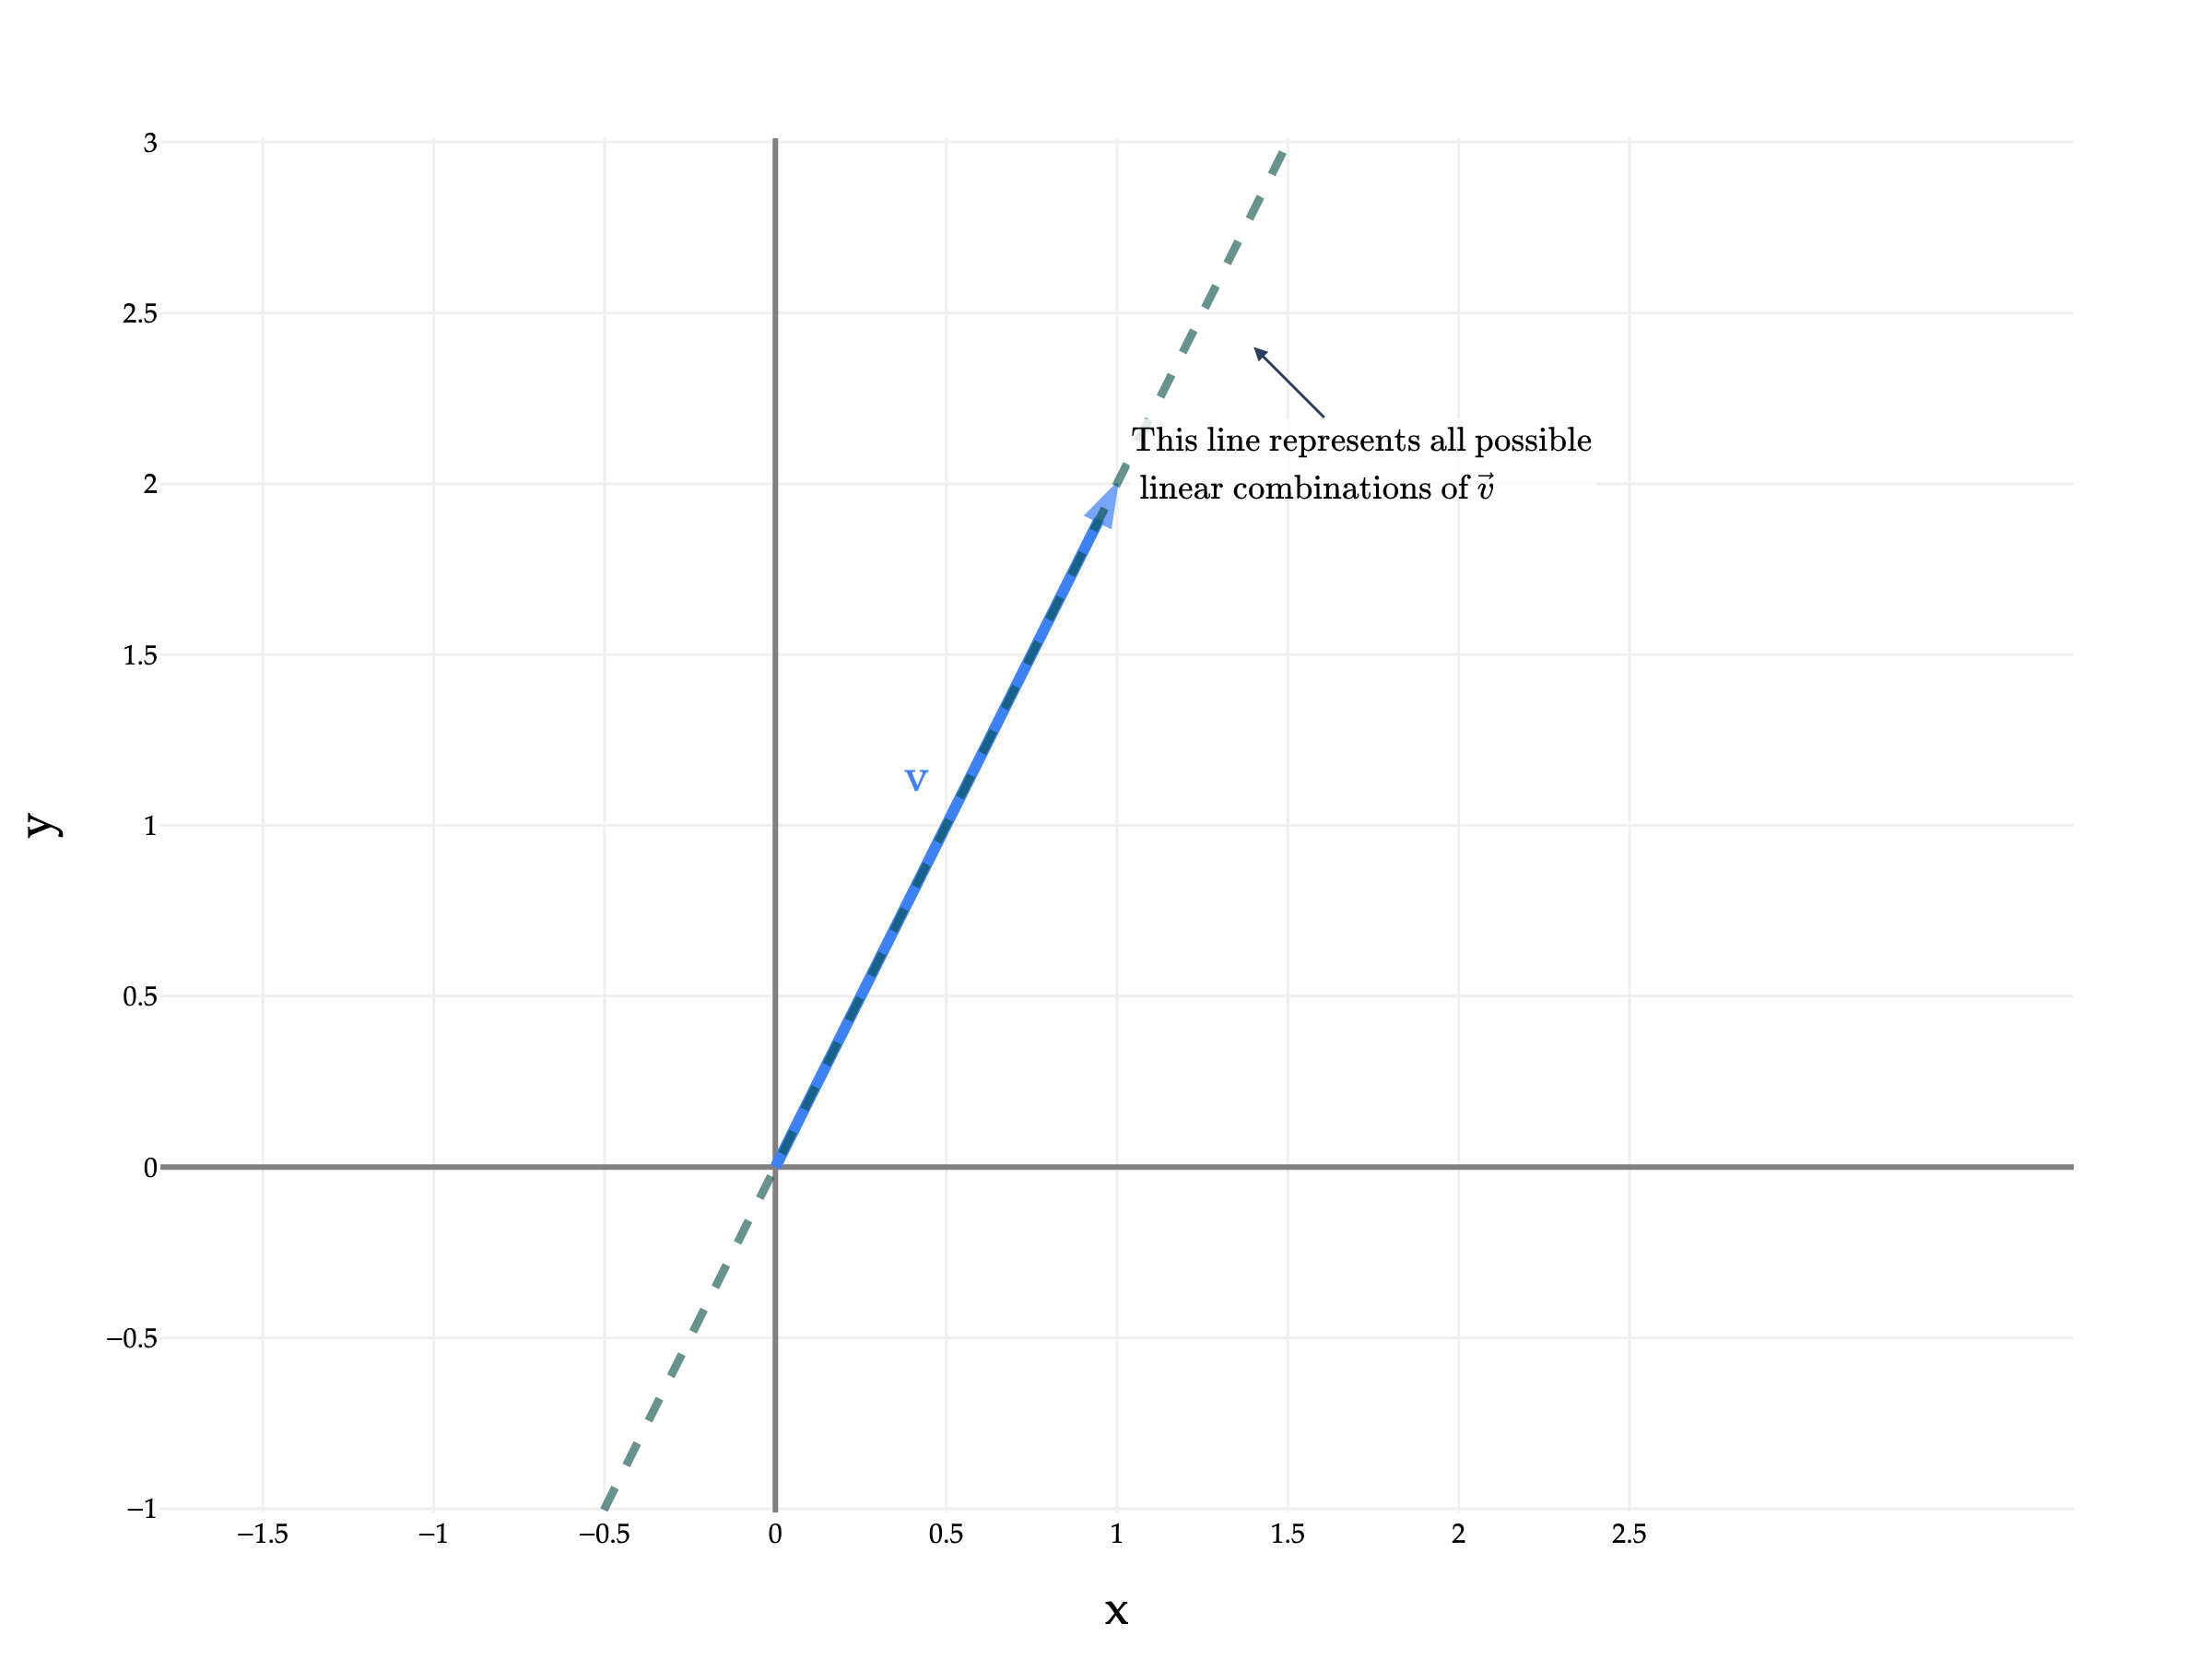

In [24]:
from utils import plot_vectors
import numpy as np
import plotly.graph_objects as go

v = (1, 2)

# Create the line spanned by v (all scalar multiples)
t = np.linspace(-2, 2, 100)
line_x = t * v[0]
line_y = t * v[1]

fig = plot_vectors([(v, "#3d81f6", r"v")], show_axis_labels=True, vdeltax=0.1)

# Add the line spanned by v
fig.add_trace(
    go.Scatter(
        x=line_x,
        y=line_y,
        mode="lines",
        line=dict(color="rgba(0,77,64,0.6)", width=3, dash="dash"),
        showlegend=False,
        hoverinfo="skip",
        zorder=0
    ),
)

# This annotation indicates the line represents all possible linear combinations of v alone
fig.add_annotation(
    x=1.5 * v[0] - 0.1,
    y=1.5 * v[1] - 0.6,
    text=r"$\text{This line represents all possible} \\\  \text{linear combinations of } \vec v$",
    showarrow=True,
    arrowhead=2,
    ax=40,
    ay=40,
    font=dict(size=12),
    bgcolor="rgba(255,255,255,0.8)"
)

fig.update_yaxes(
    scaleanchor="x",
    scaleratio=1
)

fig.update_xaxes(
    tickvals=np.arange(-1.5, 3, 0.5)
)


fig.show(renderer='png', scale=3)

There are infinitely many vectors in $\text{span}(\{{\color{#3d81f6} \begin{bmatrix} 1 \\ 2 \end{bmatrix}}\})$, including $\begin{bmatrix} 2 \\ 4 \end{bmatrix}$ and $\begin{bmatrix} -1 \\ -2 \end{bmatrix}$, and the <span style="color: #004d40; font-weight: bold;">line shown above</span> contains all of them. Notationally, we could say $$\begin{bmatrix} 2 \\ 4 \end{bmatrix} \in \text{span}(\{{\color{#3d81f6} \begin{bmatrix} 1 \\ 2 \end{bmatrix}}\})$$

### Example in $\mathbb{R}^3$

As another example, consider $\color{#3d81f6} \vec v = \begin{bmatrix} 2 \\ -1 \\ 3 \end{bmatrix}$ in $\mathbb{R}^3$. The span of $\color{#3d81f6} \vec v$ is the line through the origin and $(2, -1, 3)$.

In [25]:
from utils import plot_vectors
import numpy as np
import plotly.graph_objects as go

v = (2, -1, 3)

# Create the line spanned by v (all scalar multiples)
t = np.linspace(-2, 2, 100)
line_x = t * v[0]
line_y = t * v[1]
line_z = t * v[2]

fig = plot_vectors([(v, "#3d81f6", r"v")], show_axis_labels=True, vdeltax=0.1)

# Add the line spanned by v to the 3D plot
fig.add_trace(
    go.Scatter3d(
        x=line_x,
        y=line_y,
        z=line_z,
        mode="lines",
        line=dict(color="rgba(0,77,64,0.6)", width=5, dash="dash"),
        showlegend=False,
        hoverinfo="skip"
    )
)

# Draw small points at (0, 0, 0) and the tip of v
fig.add_trace(
    go.Scatter3d(
        x=[0, v[0]],
        y=[0, v[1]],
        z=[0, v[2]],
        mode="markers",
        marker=dict(size=4, color=["#222", "#222"]),
        showlegend=False,
        hoverinfo="skip"
    )
)

fig.update_layout(
    scene_camera=dict(
        eye=dict(x=-1.2, y=2, z=1.2)
    ),
)

fig.show()

The two marked points above are at the origin and $(2, -1, 3)$; I've marked them to emphasize that $\text{span}(\{{\color{#3d81f6} \begin{bmatrix} 2 \\ -1 \\ 3 \end{bmatrix}}\})$ is the unique line that passes through both $(2, -1, 3)$ and the origin. There are infinitely many lines that pass through $(2, -1, 3)$, but only one of those also passes through the origin.

Note that **lines are 1-dimensional objects**, regardless of the dimension of the space they live in. The line shown above is 1-dimensional in the sense that **any point on the line can be described using a single variable**. That variable is $a$ from the definition of the span:

$$\text{span}(\{{\color{#3d81f6} \begin{bmatrix} 2 \\ -1 \\ 3 \end{bmatrix}}\}) = \left\{ a {\color{#3d81f6} \begin{bmatrix} 2 \\ -1 \\ 3 \end{bmatrix}} \mid a \in \mathbb{R} \right\}$$

Give me an $a$, and I'll give you a point on the line.

### Generalization to $\mathbb{R}^n$

The fact that a single vector spans a line is true, regardless of the dimension of the vectors themselves. The span of the vector $\begin{bmatrix} 1 \\ 2 \\ \vdots \\ 100 \end{bmatrix} \in \mathbb{R}^{100}$ is the line through the origin and $(1, 2, \ldots, 100)$ in $\mathbb{R}^{100}$. We can't visualize what a line in 100-dimensional space looks like, but we know that it exists in this abstract sense.

Finally, I'll say that in the edge case where $\color{#3d81f6}\vec v = \begin{bmatrix} 0 \\ 0 \\ \vdots \\ 0 \end{bmatrix} = \vec 0$, $\text{span}(\{{\color{#3d81f6} \vec 0}\}) = \left\{ {\color{#3d81f6} \vec 0} \right\}$ is just the single point corresponding to the origin, not a line.

The fact that a single vector spans a line motivates a discussion in [Chapter 4.4](./04-lines-planes-hyperplanes.ipynb) about how to describe lines in $\mathbb{R}^n$. The short answer is that the form $y = mx + b$ only applies to lines in $\mathbb{R}^2$, and lines in $\mathbb{R}^3$ and higher must be described in **parametric form**.

$$L = \vec p_0 + tv, \qquad t \in \mathbb{R}$$

Again, [Chapter 4.4](./04-lines-planes-hyperplanes.ipynb) has more details.

---

## Span of Two Vectors

Instead of considering just a single vector, let's now consider the span of two vectors. 

### Examples in $\mathbb{R}^2$

Let's start with a simple example: the span of two vectors in $\mathbb{R}^2$. Consider

$${\color{orange}\vec v_1 = \begin{bmatrix} 2 \\ 0 \end{bmatrix}}, \qquad {\color{#3d81f6}\vec v_2 = \begin{bmatrix} 3 \\ 5 \end{bmatrix}}$$

$\text{span}(\{{\color{orange}\vec v_1}, {\color{#3d81f6}\vec v_2}\})$ is the set of all possible linear combinations of $\color{orange}\vec v_1$ and $\color{#3d81f6}\vec v_2$.

$$\text{span}(\{{\color{orange}\vec v_1}, {\color{#3d81f6}\vec v_2}\}) = \left\{ a_1 {\color{orange}\vec v_1} + a_2 {\color{#3d81f6}\vec v_2} \mid a_1, a_2 \in \mathbb{R} \right\}$$

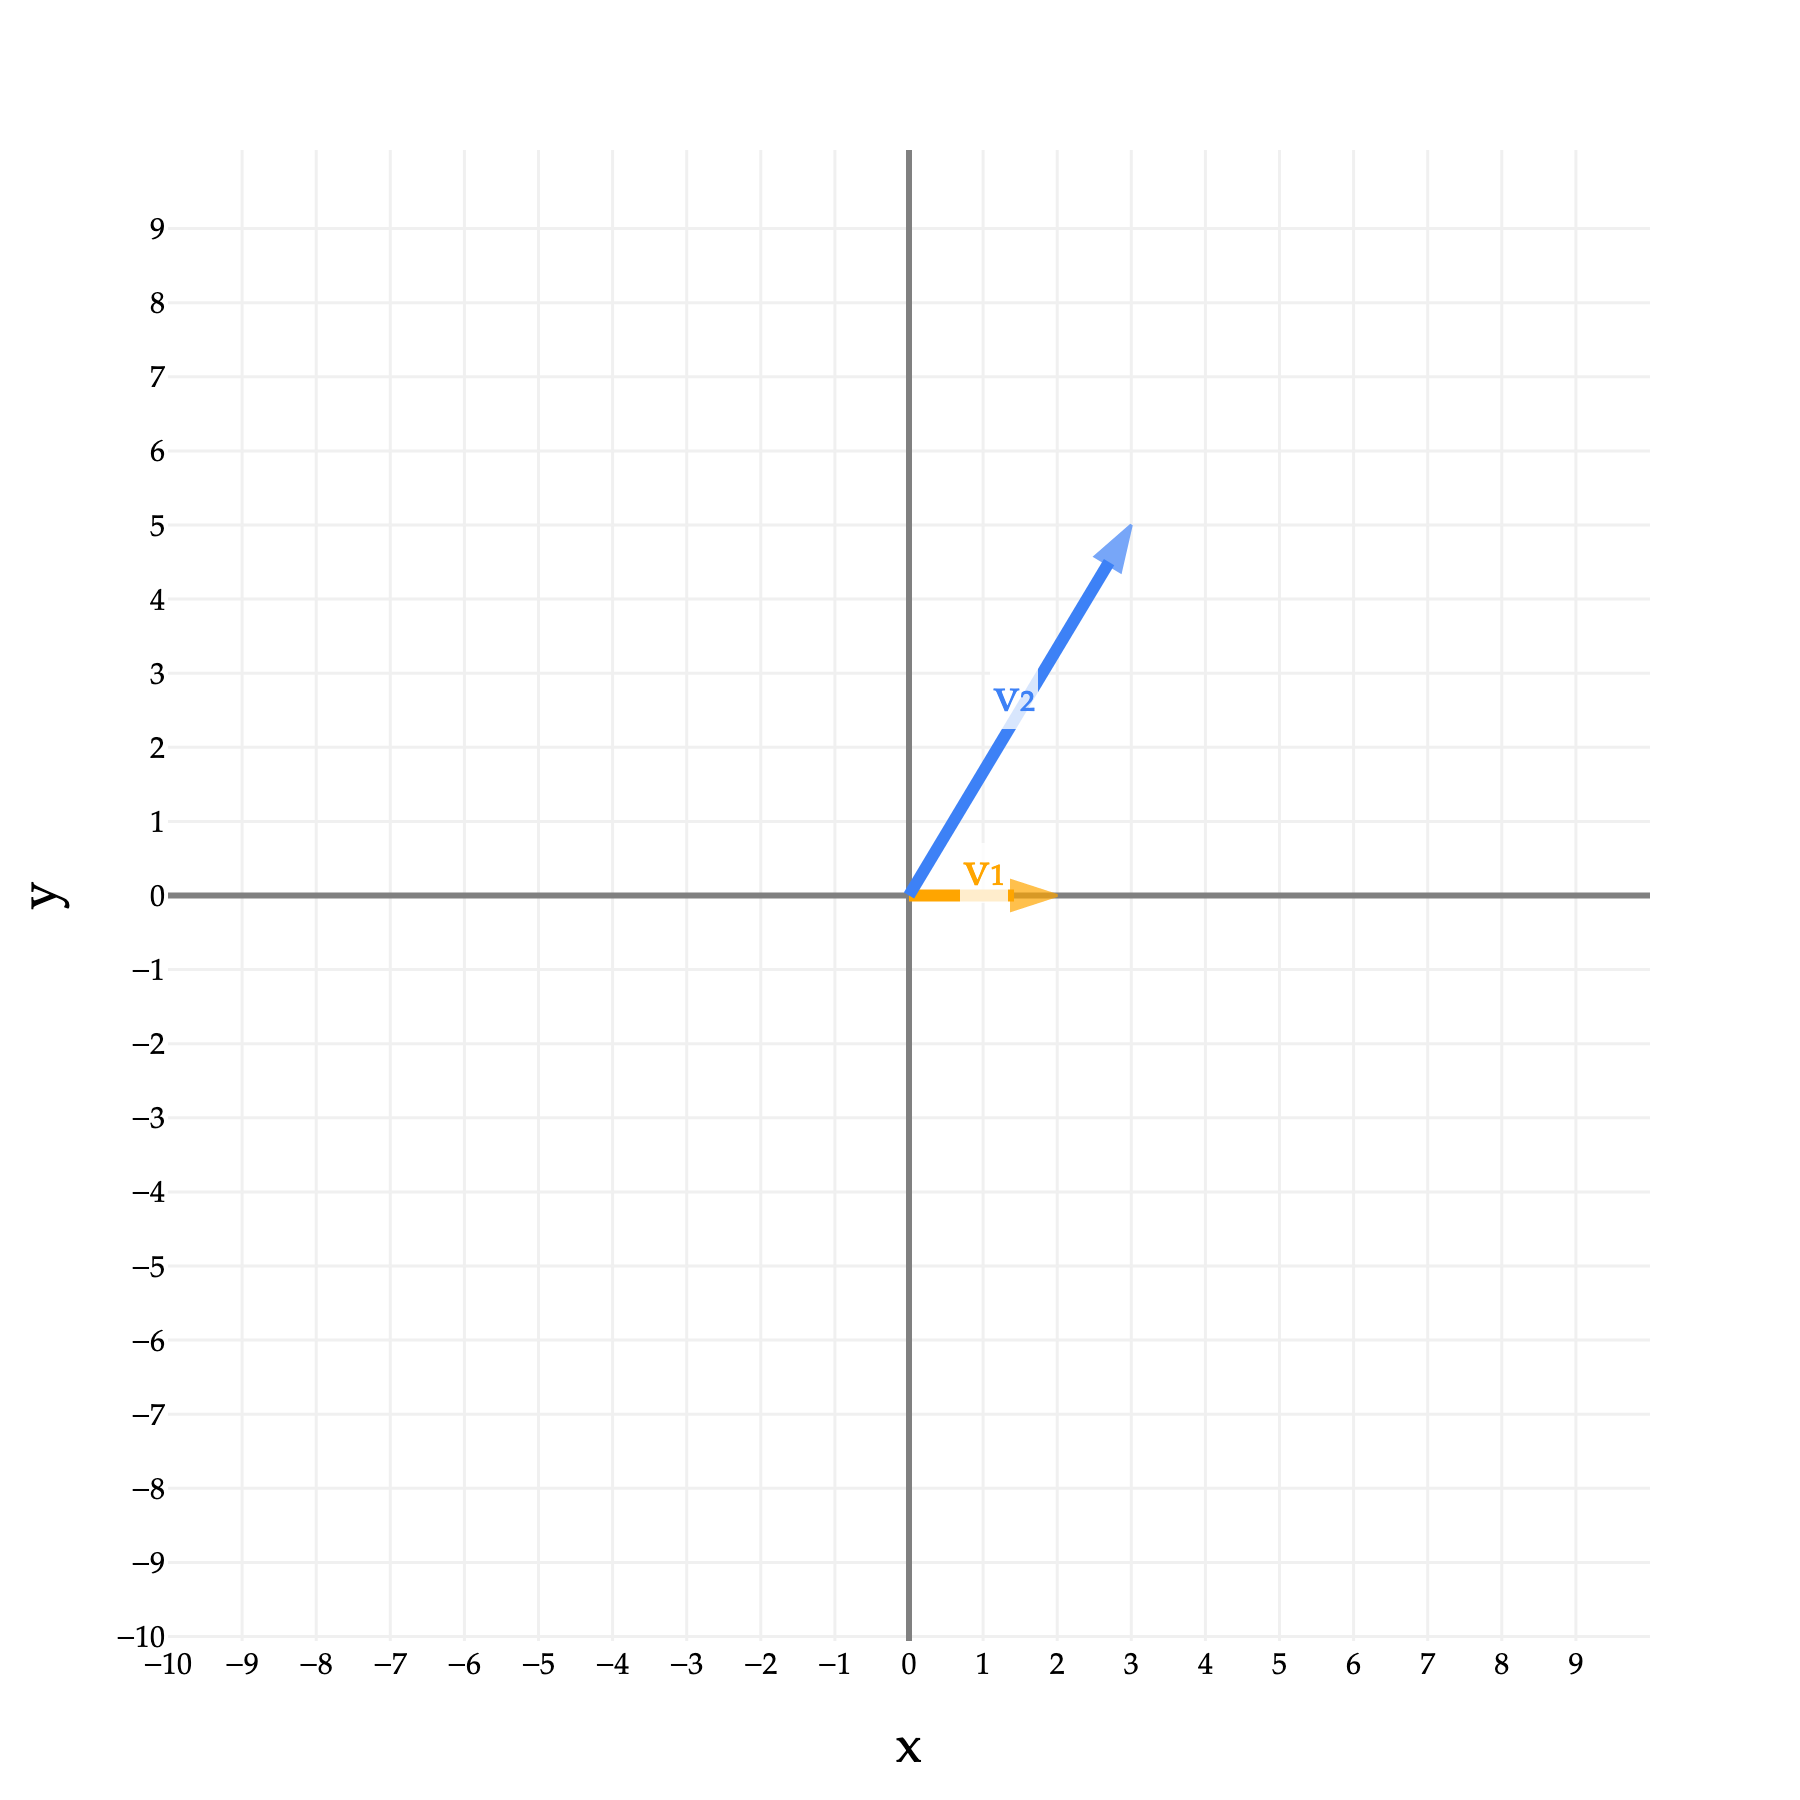

In [26]:
from utils import plot_vectors
import numpy as np
import plotly.graph_objects as go

v1 = (2, 0)
v2 = (3, 5)

fig = plot_vectors([(v1, "orange", r"v₁"), (v2, "#3d81f6", r"v₂")], show_axis_labels=True, vdeltax=0.1)

fig.update_xaxes(
    scaleanchor="y",
    scaleratio=1,
    tickvals=np.arange(-10, 10, 1)
)

fig.update_yaxes(
    scaleanchor="x",
    scaleratio=1,
    tickvals=np.arange(-10, 10, 1)
)

fig.update_layout(
    xaxis_range=[-10, 10],
    yaxis_range=[-10, 10],
    width=600,
    height=600
)

fig.show(renderer='png', scale=3)

What is the set of all possible linear combinations of $\color{orange}\vec v_1$ and $\color{#3d81f6}\vec v_2$? Using $\color{orange}\vec v_1$ and $\color{#3d81f6}\vec v_2$ as building blocks, what are all possible vectors we can reach?

Since $\color{orange}\vec v_1$ and $\color{#3d81f6}\vec v_2$ point in different directions, we can reach any point in $\mathbb{R}^2$ by choosing appropriate values of $a_1$ and $a_2$.

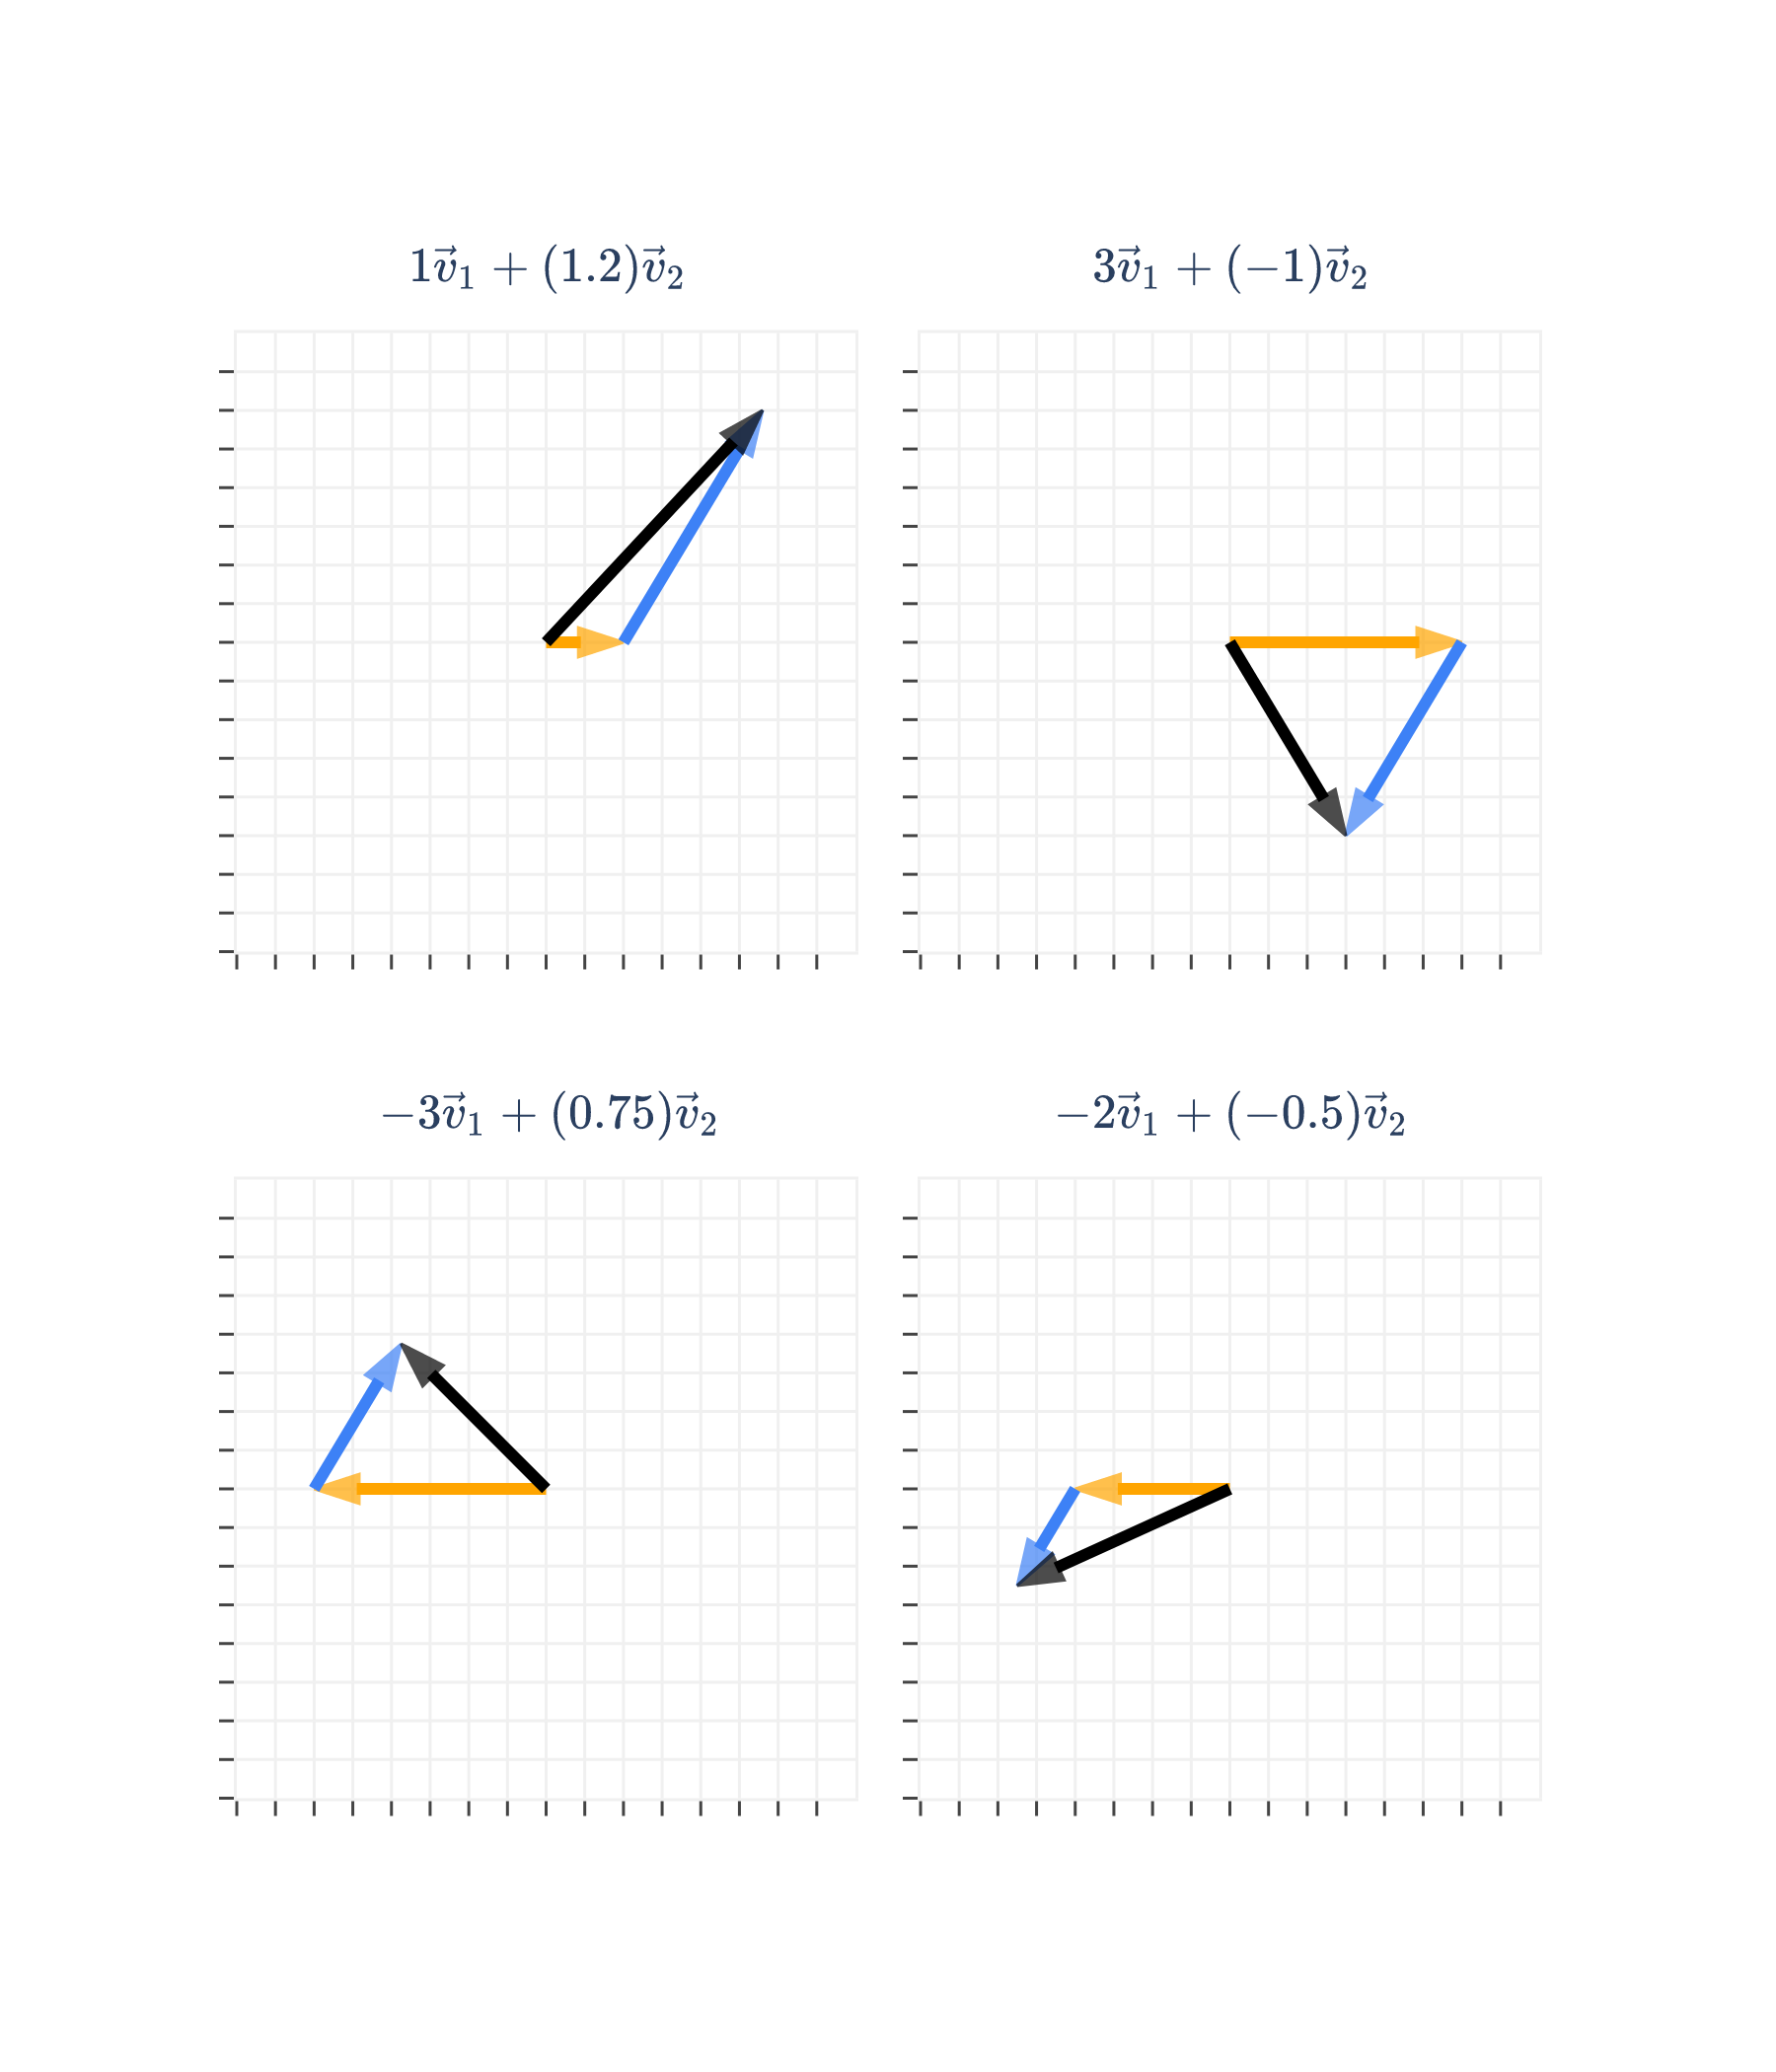

In [27]:
from utils import plot_vectors_non_origin
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

v1 = np.array([2, 0])
v2 = np.array([3, 5])

examples = [
    (1, 1.2),
    (3, -1),
    (-3, 0.75),
    (-2, -0.5)
]

# Set fixed axis range and ticks for all subplots
x_range = [-8, 8]
y_range = [-8, 8]
x_ticks = np.arange(-8, 8, 1)
y_ticks = np.arange(-8, 8, 1)

fig = make_subplots(
    rows=2, cols=2, 
    subplot_titles=[f"$${a1} \\vec v_1 + ({a2}) \\vec v_2$$" for a1, a2 in examples],
    horizontal_spacing=0.05,  # Decreased horizontal spacing
    vertical_spacing=0.1     # Decreased vertical spacing
)

for idx, (a1, a2) in enumerate(examples):
    a1v1 = a1 * v1
    a2v2 = a2 * v2
    sum_vec = a1v1 + a2v2

    vectors = [
        (((0, 0), tuple(a1v1)), "orange", None),
        ((tuple(a1v1), tuple(sum_vec)), "#3d81f6", None),
        (((0, 0), tuple(sum_vec)), "black", None)
    ]

    subfig = plot_vectors_non_origin(
        vectors,
        show_axis_labels=True,
        vdeltax=0.2,
        vdeltay=0.2,
    )

    for trace in subfig.data:
        fig.add_trace(trace, row=idx // 2 + 1, col=idx % 2 + 1)

    # Make subplot square and grid lines perfect squares
    fig.update_xaxes(
        scaleanchor=f'y{idx+1}',
        scaleratio=1,
        row=idx // 2 + 1,
        col=idx % 2 + 1,
        range=x_range,
        gridcolor="#f0f0f0",
        zeroline=False,
        showline=True,
        linewidth=1,
        linecolor="#f0f0f0",
        mirror=True,
        ticks="outside",
        tickvals=x_ticks,
        showticklabels=False,  # Hide tick labels
        constrain='domain'
    )
    fig.update_yaxes(
        scaleanchor=f'x{idx+1}',
        scaleratio=1,
        range=y_range,
        gridcolor="#f0f0f0",
        zeroline=False,
        showline=True,
        linewidth=1,
        linecolor="#f0f0f0",
        mirror=True,
        ticks="outside",
        tickvals=y_ticks,
        showticklabels=False,  # Hide tick labels
        row=idx // 2 + 1,
        col=idx % 2 + 1,
        constrain='domain'
    )

fig.update_layout(
    height=700, width=600, showlegend=False,
    plot_bgcolor="white",
    paper_bgcolor="white",
    font=dict(family="Palatino, Palatino Linotype, serif")
)
fig.show(renderer='png', scale=3)

So, if $\color{orange} \vec v_1 = \begin{bmatrix} 2 \\ 0 \end{bmatrix}$ and $\color{#3d81f6} \vec v_2 = \begin{bmatrix} 3 \\ 5 \end{bmatrix}$, $\text{span}(\{{\color{orange}\vec v_1}, {\color{#3d81f6}\vec v_2}\}) = \mathbb{R}^2$, meaning that $\color{orange} \vec v_1$ and $\color{#3d81f6} \vec v_2$ span the entire $xy$-**plane**. 

Equivalently, for **any** vector $\vec b \in \mathbb{R}^2$, there exist $a_1$ and $a_2$ such that $a_1 {\color{orange}\vec v_1} + a_2 {\color{#3d81f6}\vec v_2} = \vec b$.

But, not every pair of vectors in $\mathbb{R}^2$ spans the entire plane. For example, consider the vectors 

$${\color{orange}\vec v_1 = \begin{bmatrix} 1 \\ 1 \end{bmatrix}}, \qquad \color{#3d81f6}\vec v_2 = \begin{bmatrix} 2 \\ 2 \end{bmatrix}$$

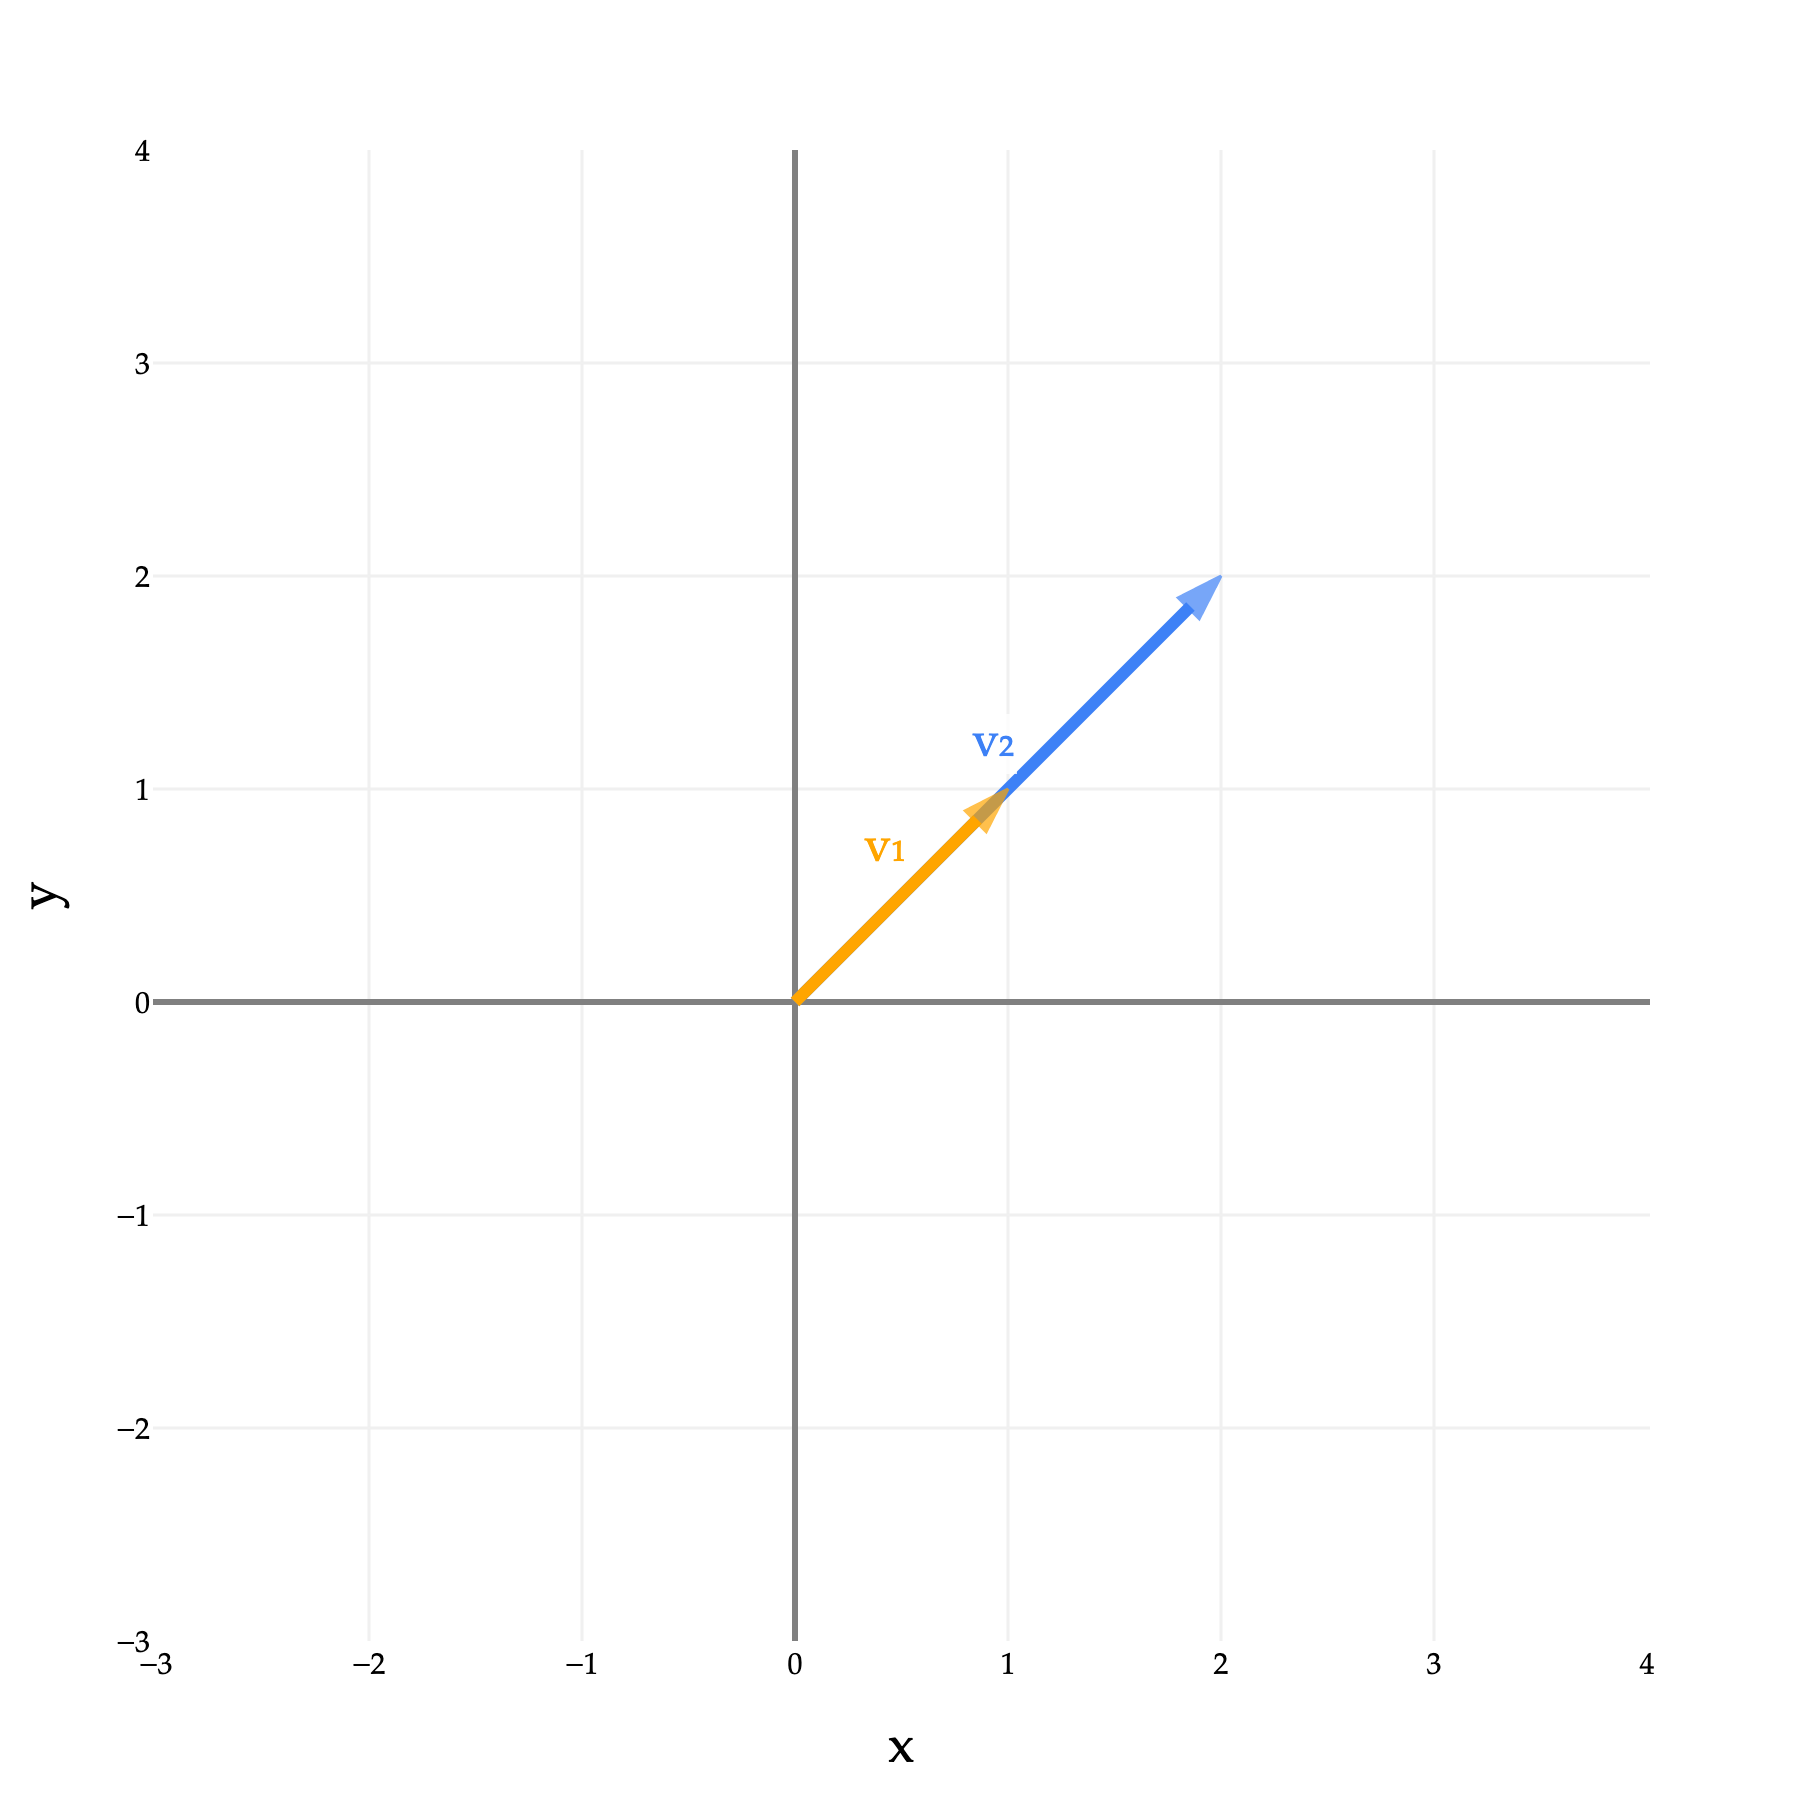

In [28]:
from utils import plot_vectors
import numpy as np
import plotly.graph_objects as go

v1 = (1, 1)
v2 = (2, 2)

fig = plot_vectors([(v2, "#3d81f6", r"v₂"), (v1, "orange", r"v₁"), ], show_axis_labels=True, vdeltax=0.1)

fig.update_xaxes(
    scaleanchor="y",
    scaleratio=1,
    # tickvals=np.arange(-10, 10, 1)
)

fig.update_yaxes(
    scaleanchor="x",
    scaleratio=1,
    # tickvals=np.arange(-10, 10, 1)
)

fig.update_layout(
    xaxis_range=[-3, 4],
    yaxis_range=[-3, 4],
    width=600,
    height=600
)

fig.show(renderer='png', scale=3)

$\color{orange}\vec v_1$ and $\color{#3d81f6}\vec v_2$ are scalar multiples of each other – i.e. they are **collinear** – so they only span a line, despite there being two vectors. They span the same line that either one of them spans individually, which is the line through the origin, $(1, 1)$, and $(2, 2)$.

If we start with just $\color{orange}\vec v_1$, the vector $\color{#3d81f6}\vec v_2$ doesn't "unlock" or "contribute" any new vectors to the span, since $\color{#3d81f6}\vec v_2$ is just a scalar multiple of $\color{orange}\vec v_1$. As we will soon see, this means that the vectors $\color{orange}\vec v_1$ and $\color{#3d81f6}\vec v_2$ are **linearly dependent**.

If we didn't immediately recognize that $\color{#3d81f6}\vec v_2$ is just a scalar multiple of $\color{orange}\vec v_1$ and tried to write (for example)

$$\vec b = \begin{bmatrix} 8 \\ 11 \end{bmatrix}$$ as a linear combination of $\color{orange}\vec v_1$ and $\color{#3d81f6}\vec v_2$, we might think it's possible, since we're working with a system of two equations and two unknowns.

$$a_1 {\color{orange} \begin{bmatrix} 1 \\ 1 \end{bmatrix}} + a_2 {\color{#3d81f6} \begin{bmatrix} 2 \\ 2 \end{bmatrix}} = \begin{bmatrix} 8 \\ 11 \end{bmatrix}$$

But, when you go to solve, you'll find

$$a_1 + 2a_2 = 8$$
$$a_1 + 2a_2 = 11$$

which is a contradiction, since $8 \neq 11$, meaning we can't make $\vec b$ as a linear combination of $\color{orange}\vec v_1$ and $\color{#3d81f6}\vec v_2$.

And, for the vectors $\vec b$ that are in $\text{span}(\{ {\color{orange}\vec v_1}, {\color{#3d81f6}\vec v_2} \})$, there are **infinitely many** ways to write them as linear combinations of $\color{orange}\vec v_1$ and $\color{#3d81f6}\vec v_2$. For example,

$$1 {\color{orange} \begin{bmatrix} 1 \\ 1 \end{bmatrix}} + 3 {\color{#3d81f6} \begin{bmatrix} 2 \\ 2 \end{bmatrix}} = \begin{bmatrix} 7 \\ 7 \end{bmatrix}$$

$$7 {\color{orange} \begin{bmatrix} 1 \\ 1 \end{bmatrix}} + 0 {\color{#3d81f6} \begin{bmatrix} 2 \\ 2 \end{bmatrix}} = \begin{bmatrix} 7 \\ 7 \end{bmatrix}$$

$$-35 {\color{orange} \begin{bmatrix} 1 \\ 1 \end{bmatrix}} + 21 {\color{#3d81f6} \begin{bmatrix} 2 \\ 2 \end{bmatrix}} = \begin{bmatrix} 7 \\ 7 \end{bmatrix}$$

When solving for $a_1$ and $a_2$, I like to avoid situations where there are infinitely many solutions, since I'd like to make sure that if we all solve the same problem, we'll all get the same answer. Remember that all of this connects back to linear regression and machine learning; the analog of $a_1$ and $a_2$ are the parameters of a linear model, and we'd like to have interpretable parameter values so that we can see how the inputs of a model relate to the outputs.

Back to the main idea. In $\mathbb{R}^2$, the span of two vectors is a line if the vectors are collinear, and the entire $xy$-plane otherwise.

### Example in $\mathbb{R}^3$

Similar results hold for the span of two vectors in $\mathbb{R}^3$. Hopefully I've convinced you that

$$\text{span}(\{ \begin{bmatrix} 5 \\ 2 \\ 1 \end{bmatrix}, \begin{bmatrix} 10 \\ 4 \\ 2 \end{bmatrix} \}) = \underbrace{\text{span}(\{ \begin{bmatrix} 5 \\ 2 \\ 1 \end{bmatrix} \})}_{\text{a line in }\mathbb{R}^3}$$

since $\begin{bmatrix} 10 \\ 4 \\ 2 \end{bmatrix}$ is just a scalar multiple of $\begin{bmatrix} 5 \\ 2 \\ 1 \end{bmatrix}$.

Let's see a more interesting example. Consider the vectors $${\color{orange}\vec v_1 = \begin{bmatrix} 5 \\ 2 \\ 1 \end{bmatrix}}, \quad \color{#3d81f6}\vec v_2 = \begin{bmatrix} -2 \\ 3 \\ 0 \end{bmatrix}$$

You'll see them below, along with some of their linear combinations.

In [29]:
from utils import plot_vectors
import numpy as np
import plotly.graph_objects as go

v1 = (5, 2, 1)
v2 = (-2, 3, 0)

lc1 = tuple(-0.5 * np.array(v1) - 0.5 * np.array(v2))
lc2 = tuple(-2 * np.array(v1) + 3 * np.array(v2))
lc3 = tuple(1.25 * np.array(v1) - 1 * np.array(v2))

fig = plot_vectors([(v1, "orange", r"v₁"), 
                    (v2, "#3d81f6", r"v₂"),
                    (lc1, "gray", r""),
                    (lc2, "gray", r""),
                    (lc3, "gray", r"")
                    ], show_axis_labels=True, vdeltax=0.3, vdeltay=1)

fig.update_xaxes(
    scaleanchor="y",
    scaleratio=1,
    tickvals=np.arange(-10, 10, 1)
)

fig.update_yaxes(
    scaleanchor="x",
    scaleratio=1,
    tickvals=np.arange(-10, 10, 1)
)

fig.update_layout(
    xaxis_range=[-10, 10],
    yaxis_range=[-10, 10],
    width=600,
    height=600,
    scene_camera=dict(
        eye=dict(x=-1.2, y=2, z=1.2)
    ),
)

fig.show()

As was the case in $\mathbb{R}^2$, since $\color{orange} \vec v_1$ and $\color{#3d81f6} \vec v_2$ aren't collinear, they span a plane. In $\mathbb{R}^2$, there was only one possible plane that two vectors could span, because all of $\mathbb{R}^2$ itself is a plane, but in $\mathbb{R}^3$ there are infinitely many planes. 

A plane is a flat surface that extends infinitely in all directions, with the property that if you connect any two points on the plane, the line connecting them lies entirely on the plane.

In [30]:
from utils import plot_vectors
import numpy as np
import plotly.graph_objects as go

v1 = (5, 2, 1)
v2 = (-2, 3, 0)

lc1 = tuple(-0.5 * np.array(v1) - 0.5 * np.array(v2))
lc2 = tuple(-2 * np.array(v1) + 3 * np.array(v2))
lc3 = tuple(1.25 * np.array(v1) - 1 * np.array(v2))

fig = plot_vectors([(v1, "orange", r"v₁"), 
                    (v2, "#3d81f6", r"v₂"),
                    (lc1, "gray", r""),
                    (lc2, "gray", r""),
                    (lc3, "gray", r"")
                    ], show_axis_labels=True, vdeltax=0.3, vdeltay=1)

# Add the plane spanned by v1 and v2
plane_extent = 20
num_points = 3

s_range = np.linspace(-plane_extent, plane_extent, num_points)
t_range = np.linspace(-plane_extent, plane_extent, num_points)
s_grid, t_grid = np.meshgrid(s_range, t_range)

plane_x = s_grid * v1[0] + t_grid * v2[0]
plane_y = s_grid * v1[1] + t_grid * v2[1]
plane_z = s_grid * v1[2] + t_grid * v2[2]

fig.add_trace(go.Surface(
    x=plane_x,
    y=plane_y,
    z=plane_z,
    opacity=0.8,
    colorscale=[[0, 'rgba(61,129,246,0.3)'], [1, 'rgba(61,129,246,0.3)']],
    showscale=False,
))

fig.update_xaxes(
    scaleanchor="y",
    scaleratio=1,
    tickvals=np.arange(-10, 10, 1)
)

fig.update_yaxes(
    scaleanchor="x",
    scaleratio=1,
    tickvals=np.arange(-10, 10, 1)
)

fig.update_layout(
    xaxis_range=[-10, 10],
    yaxis_range=[-10, 10],
    width=600,
    height=600,
    scene_camera=dict(
        eye=dict(x=-1.2, y=2, z=1.2)
    ),
)

fig.show()

So,

$$\text{span}(\{ {\color{orange} \vec v_1 }, {\color{#3d81f6} \vec v_2} \}) = \underbrace{\{ a_1 {\color{orange} \vec v_1} + a_2 {\color{#3d81f6} \vec v_2} \mid a_1, a_2 \in \mathbb{R} \}}_{ \text{the plane above} }$$

I hope to have convinced you earlier that lines are 1-dimensional objects, since you only need a single "variable" to describe any point on a given line.

Similarly, **planes are 2-dimensional objects**, since you need two "variables" to describe any point on a given plane. In the standard $xy$-plane, all you need to describe a point is an $x$ coordinate and a $y$ coordinate. Effectively, every vector in $\mathbb{R}^2$ can be written as a linear combination of the "default" (formally **basis**) vectors $\begin{bmatrix} 1 \\ 0 \end{bmatrix}$ and $\begin{bmatrix} 0 \\ 1 \end{bmatrix}$.

$$\text{any point in } \mathbb{R}^2 = x \begin{bmatrix} 1 \\ 0 \end{bmatrix} + y \begin{bmatrix} 0 \\ 1 \end{bmatrix}$$

The plane shown above is also 2-dimensional, despite living in $\mathbb{R}^3$, since all I need are two variables to describe any point on it. The variables I need are $a_1$ and $a_2$, which are the multipliers on $\color{orange} \vec v_1$ and $\color{#3d81f6} \vec v_2$, respectively.

$$\text{any point in } \text{span}(\{ {\color{orange} \vec v_1 }, {\color{#3d81f6} \vec v_2} \}) = a_1 {\color{orange} \begin{bmatrix} 5 \\ 2 \\ 1 \end{bmatrix}} + a_2 {\color{#3d81f6} \begin{bmatrix} -2 \\ 3 \\ 0 \end{bmatrix}}$$

Think of $\color{orange} \vec v_1$ and $\color{#3d81f6} \vec v_2$ as defining a new coordinate system for the plane that they span, where the coordinates themselves are the scalars $a_1$ and $a_2$. $a_1$ and $a_2$ can be arbitrarily large or small, which is what allows the plane to extend infinitely.

The picture above makes clear that there are many vectors in $\text{span}(\{ {\color{orange} \vec v_1 }, {\color{#3d81f6} \vec v_2} \})$, but also many vectors in $\mathbb{R}^3$ that are not in the span. $a_1 {\color{orange} \vec v_1} + a_2 {\color{#3d81f6} \vec v_2} = \vec b$ has a solution for $a_1$ and $a_2$ if and only if $\vec b$ lies in the plane above.

:::{attention} Again, Read Chapter 4.4!
To actually find the equation of the plane above in standard form,

$$ax + by + cz + d = 0$$

we need a tool called the **cross product**. We talk about this, and other details about lines and planes, in [Chapter 4.4](./04-lines-planes-hyperplanes.ipynb). (I know I already said this, but it's really important!)
:::

### Subspaces of $\mathbb{R}^n$

What if we're dealing with two vectors in some arbitrary $\mathbb{R}^n$? Consider

$$\vec v_1 = \begin{bmatrix} 5 \\ 1 \\ 3 \\ 2 \\ -8 \end{bmatrix}, \qquad \vec v_2 = \begin{bmatrix} 0 \\ 1 \\ 4 \\ 0 \\ 1 \end{bmatrix}$$

These vectors live in $\mathbb{R}^5$, but what they span is a "plane" in $\mathbb{R}^5$. The more typical way of phrasing this is that these vectors span a **2-dimensional subspace** of $\mathbb{R}^5$. 

We will formally define vector spaces and subspaces in [Chapter 4.3](./03-vector-spaces-basis-dimension.ipynb), but for now, **think of a subspace as a flat object that passes through the origin and contains all linear combinations of some set of vectors**. 

- A line through the origin is a 1-dimensional subspace.
- A plane through the origin is a 2-dimensional subspace.
- In higher dimensions, we'll have 3-dimensional subspaces, 4-dimensional subspaces, and so on.

(A line that doesn't pass through the origin is still a line, but isn't a subspace, since subspaces must pass through the origin.)

Such a line is an **affine line**: a translated one-dimensional subspace. We'll introduce affine lines, planes, and subspaces in [Chapter 4.4](./04-lines-planes-hyperplanes.ipynb#lines-in-parametric-form).

The dimension of a subspace is the number of coordinates you need to describe any point in the subspace.

So although $\vec v_1 = \begin{bmatrix} 5 \\ 1 \\ 3 \\ 2 \\ -8 \end{bmatrix}$ and $\vec v_2 = \begin{bmatrix} 0 \\ 1 \\ 4 \\ 0 \\ 1 \end{bmatrix}$ sit inside $\mathbb{R}^5$, what they span is not all of $\mathbb{R}^5$, but rather a 2-dimensional "slice" of it, consisting of all linear combinations of $\vec v_1$ and $\vec v_2$. Any point in that subspace can be described using two coordinates, like $a_1$ and $a_2$ in

$$\text{any point in } \text{span}(\{ {\vec v_1 }, {\vec v_2} \}) = a_1 { \begin{bmatrix} 5 \\ 1 \\ 3 \\ 2 \\ -8 \end{bmatrix}} + a_2 { \begin{bmatrix} 0 \\ 1 \\ 4 \\ 0 \\ 1 \end{bmatrix}}$$

---

## Span of Three Vectors

So far, as special cases, we've considered the span of one vector and the span of two vectors. The case of three vectors is the last special case I'll cover, and then we'll generalize to any number of vectors in any $\mathbb{R}^n$.

### Examples in $\mathbb{R}^2$

Suppose we have three vectors in $\mathbb{R}^2$. What are their possible arrangements?

1. All three are the zero vector, $\vec 0$.
2. All three are collinear, meaning they lie on the same line.
3. Two are collinear, and the third points in a different direction.
4. All three point in different directions.

In all of these cases, the "largest" their span can be is all of $\mathbb{R}^2$. Case 3 and Case 4 are shown below, on the left and right, respectively.

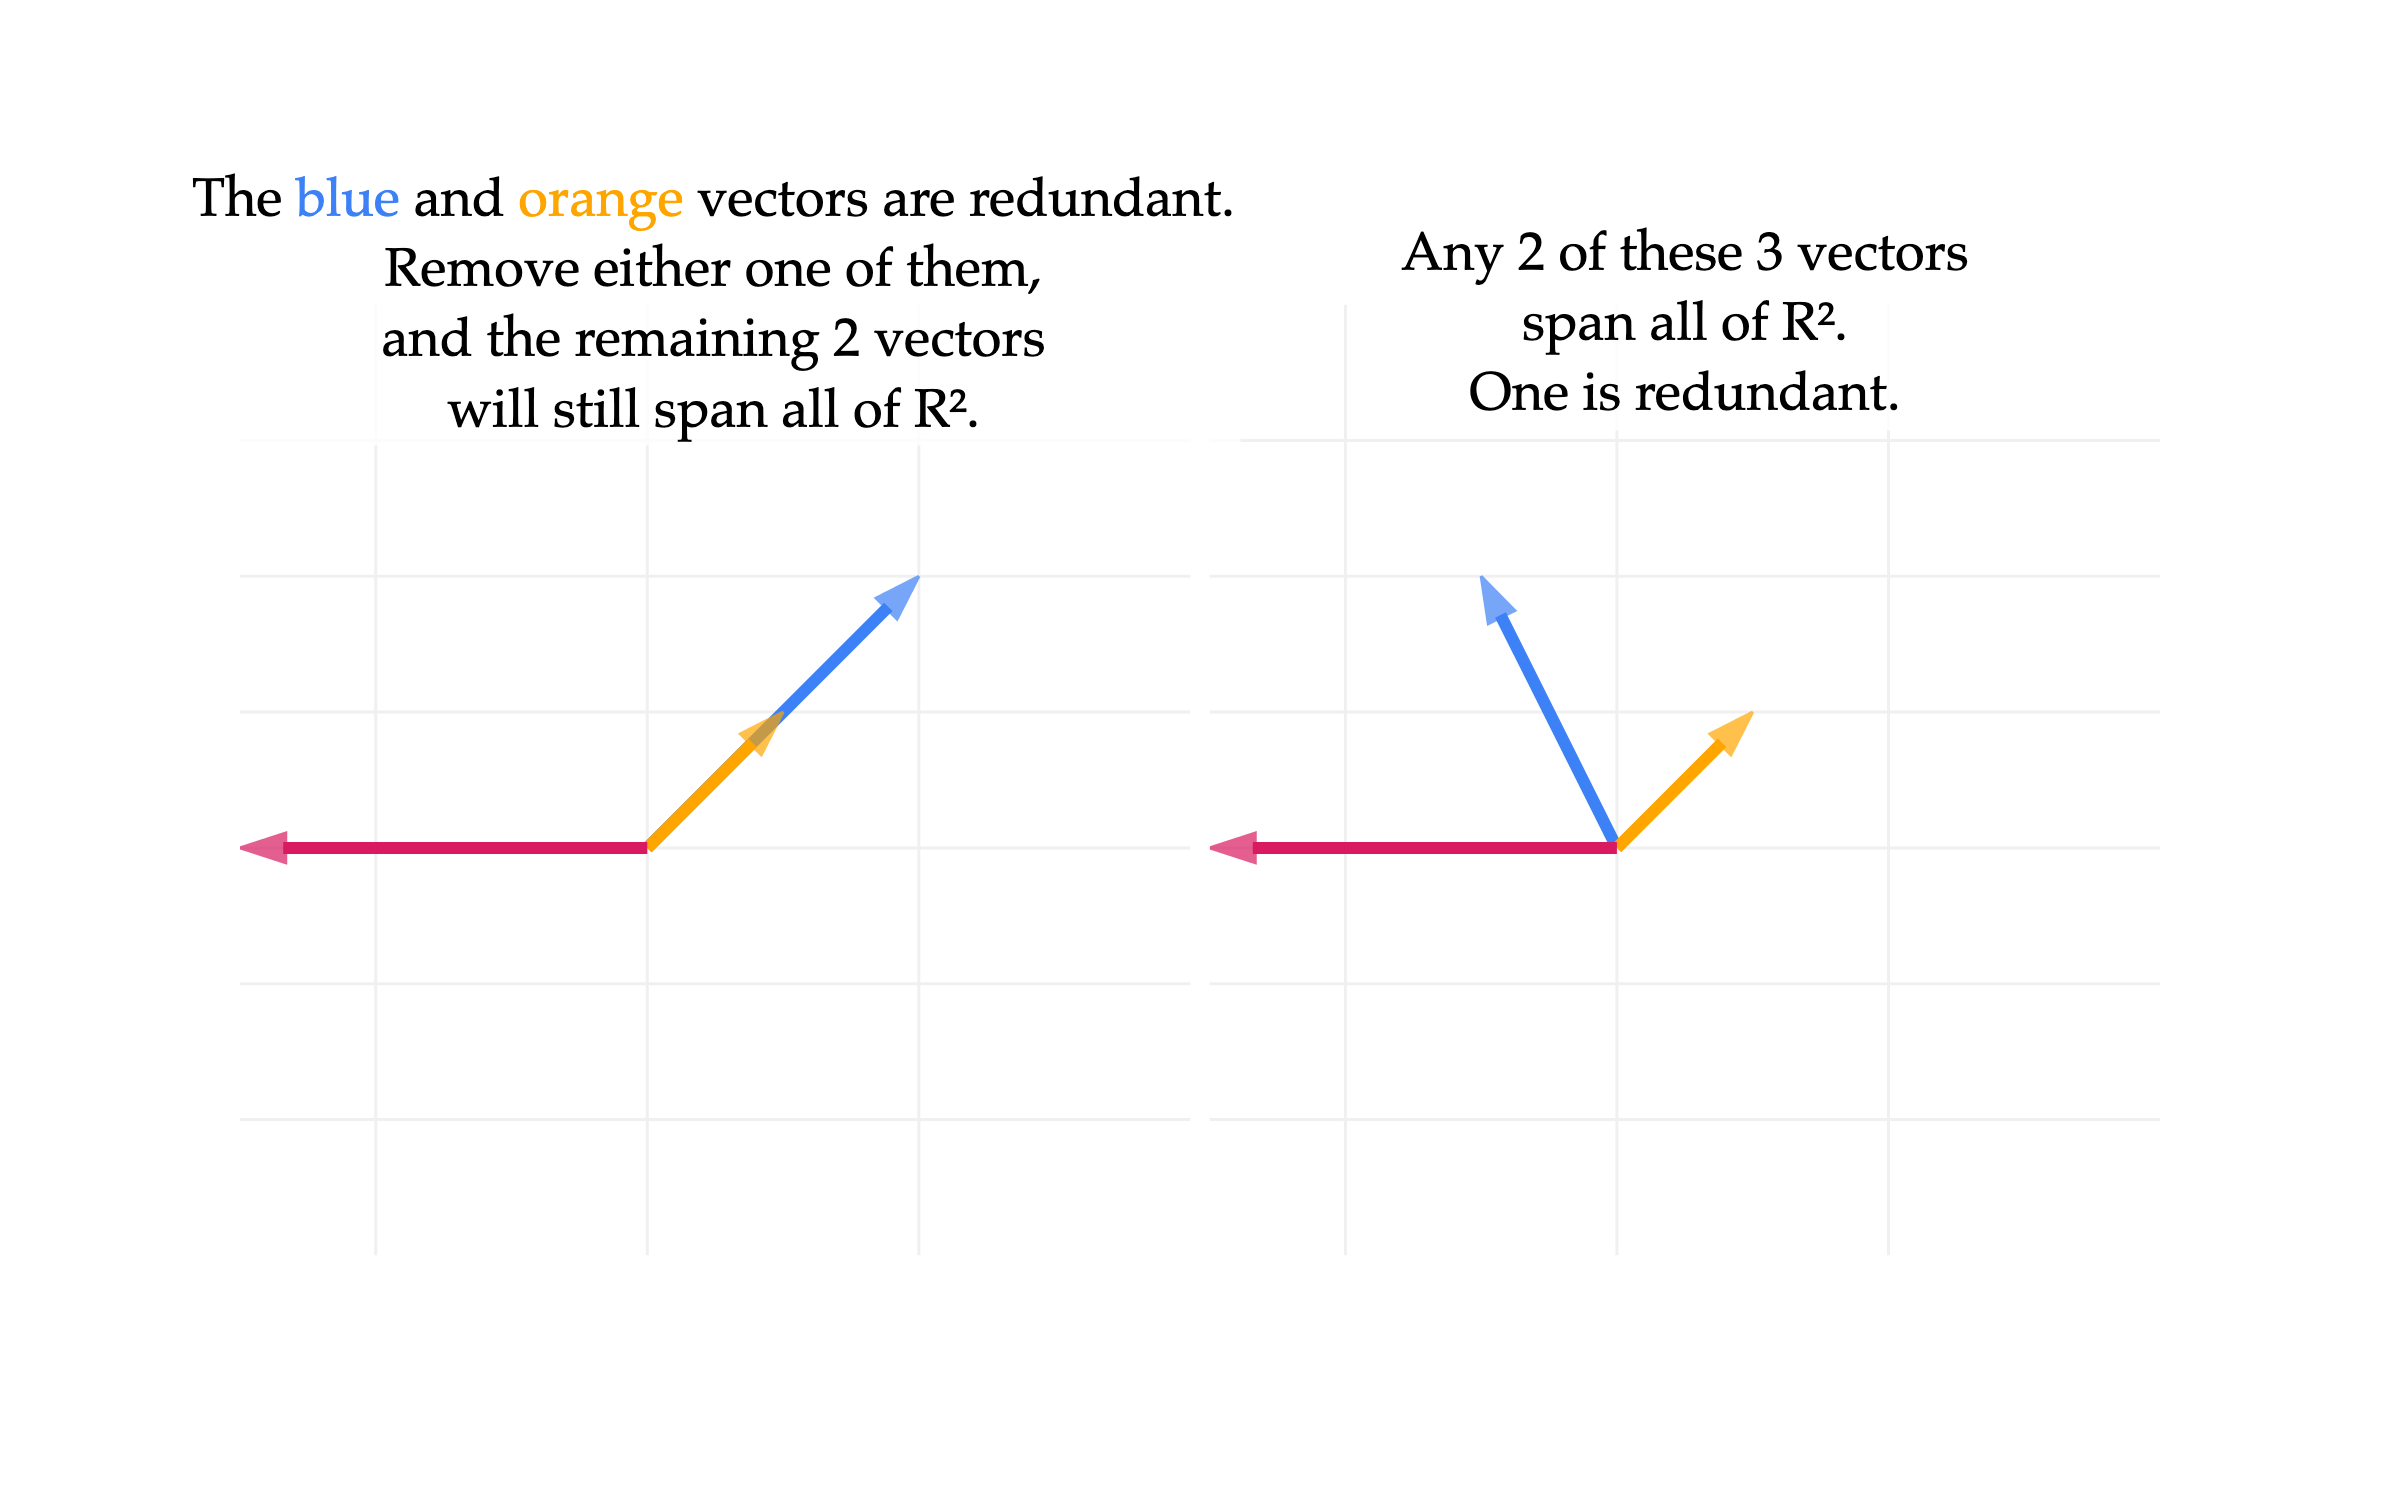

In [48]:
from utils import plot_vectors
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np

# Vectors
v1 = (1, 1)
v2_a = (2, 2)
v2_b = (-1, 2)
v3 = (-3, 0)

# Common style for axes/layout
common_axis = dict(
    gridcolor="#f0f0f0",
    griddash="solid",
    showgrid=True,
    zeroline=True,
    zerolinecolor="#f0f0f0",
    zerolinewidth=1,
    constrain="domain",
    showticklabels=False,
    title_text=None,
)
common_layout = dict(
    xaxis_range=[-3, 4],
    yaxis_range=[-3, 4],
    plot_bgcolor="white",
    paper_bgcolor="white",
    font_family="Palatino",
    font_size=18,
)

# Helper to generate a figure for a given v2
def make_vector_fig(v2, label):
    fig = plot_vectors(
        [(v2, "#3d81f6", r"v₂"), (v1, "orange", r"v₁"), (v3, "#d81b60", r"v₃")],
        show_axis_labels=False,
        vdeltax=0.1,
    )
    fig.update_xaxes(scaleanchor="y", scaleratio=1, **common_axis)
    fig.update_yaxes(scaleanchor="x", scaleratio=1, **common_axis)
    fig.update_layout(**common_layout)
    return fig

# Two separate figs
fig1 = make_vector_fig(v2_a, "v₂ = (2, 2)")
fig2 = make_vector_fig(v2_b, "v₂ = (-1, 2)")

# Combine in subplots
subplot_fig = make_subplots(
    rows=1, cols=2, horizontal_spacing=0.01
)

for trace in fig1.data:
    subplot_fig.add_trace(trace, row=1, col=1)
for trace in fig2.data:
    subplot_fig.add_trace(trace, row=1, col=2)

subplot_fig.update_xaxes(**common_axis, range=[-3, 4], row=1, col=1)
subplot_fig.update_yaxes(**common_axis, range=[-3, 4], row=1, col=1,
                         scaleanchor="x", scaleratio=1)
subplot_fig.update_xaxes(**common_axis, range=[-3, 4], row=1, col=2)
subplot_fig.update_yaxes(**common_axis, range=[-3, 4], row=1, col=2,
                         scaleanchor="x", scaleratio=1)

# Annotate the left graph (col 1) to indicate we only need one of the blue or orange vectors
subplot_fig.add_annotation(
    text=r"The <span style='color: #3d81f6'>blue</span> and <span style='color: orange'>orange</span> vectors are redundant.<br>Remove either one of them,<br>and the remaining 2 vectors<br>will still span all of R².",
    x=0.5, y=4,
    xref="x1", yref="y1",
    showarrow=False,
    font=dict(size=18, color="black"),
    bgcolor="rgba(255,255,255,0.8)",
    # bordercolor="black",
    borderwidth=1,
)
# Annotate the right graph (col 2) to indicate any 2 of the 3 vectors will span the same plane
subplot_fig.add_annotation(
    text=r"Any 2 of these 3 vectors<br>span all of R².<br>One is redundant.",
    x=0.5, y=3.85,
    xref="x2", yref="y2",
    showarrow=False,
    font=dict(size=18, color="black"),
    bgcolor="rgba(255,255,255,0.8)",
    borderwidth=1,
)

subplot_fig.update_layout(width=800, height=500, showlegend=False, **common_layout)
subplot_fig.show(renderer="png", scale=3)


In the left example, $\color{#d81b60} \vec v_3 = \begin{bmatrix} -3 \\ 0 \end{bmatrix}$ travels in a direction that $\color{orange} \vec v_1 = \begin{bmatrix} 1 \\ 1 \end{bmatrix}$ and $\color{#3d81f6} \vec v_2 = \begin{bmatrix} 2 \\ 2 \end{bmatrix}$ don't, so removing $\color{#d81b60} \vec v_3$ would impact the span (it would drop from $\mathbb{R}^2$ to a line). But, we don't need both $\color{orange} \vec v_1$ and $\color{#3d81f6} \vec v_2$ to span $\mathbb{R}^2$, since $\color{orange} \vec v_1$ already travels in the direction of $\color{#3d81f6} \vec v_2$.

In the right example, where

$${\color{orange}\vec v_1 = \begin{bmatrix} 1 \\ 1 \end{bmatrix}}, \quad {\color{#3d81f6}\vec v_2 = \begin{bmatrix} -1 \\ 2 \end{bmatrix}}, \quad {\color{#d81b60}\vec v_3 = \begin{bmatrix} -3 \\ 0 \end{bmatrix}}$$

Any two of these vectors will span the entirety of $\mathbb{R}^2$, meaning that if you pick any two of them, you can recreate the third one. These three vectors are linearly dependent.

$$\text{span}(\{ {\color{orange}\vec v_1}, {\color{#3d81f6}\vec v_2}, {\color{#d81b60}\vec v_3} \}) = \text{span}(\{ {\color{orange}\vec v_1}, {\color{#3d81f6}\vec v_2} \}) = \text{span}(\{ {\color{orange}\vec v_1}, {\color{#d81b60}\vec v_3} \}) = \text{span}(\{ {\color{#3d81f6}\vec v_2}, {\color{#d81b60}\vec v_3} \}) = \mathbb{R}^2$$

<br>

### Examples in $\mathbb{R}^3$

Moving on up to $\mathbb{R}^3$, instead of considering all possible arrangements, let me enumerate their possible spans.

1. All three are the zero vector, $\vec 0$. (Annoying edge case, but I'm including it for completeness.)
1. All three are collinear, meaning they span a line.
1. All three are on the same plane, meaning they span that same plane.
1. None of the above, meaning they span all of $\mathbb{R}^3$.

As before, Case 1 and Case 2 are easy enough to reason about. First, let's consider Case 3. Suppose

$${\color{orange}\vec v_1 = \begin{bmatrix} 1 \\ 1 \\ 1 \end{bmatrix}}, \quad {\color{#3d81f6}\vec v_2 = \begin{bmatrix} 1 \\ -2 \\ -3 \end{bmatrix}}, \quad {\color{#d81b60}\vec v_3 = \begin{bmatrix} -3 \\ 0 \\ 1 \end{bmatrix}}$$

In [71]:
from utils import plot_vectors
import numpy as np
import plotly.graph_objects as go

v1 = (1, 1, 1)
v2 = (1, -2, -3)
v3 = (-3, 0, 1)

fig = plot_vectors([(v1, "orange", r"v₁"), 
                    (v2, "#3d81f6", r"v₂"),
                    (v3, "#d81b60", r"v₃"),
                    ], show_axis_labels=True, vdeltax=0.3, vdeltay=1)

# Add the plane spanned by v1 and v2
plane_extent = 30
num_points = 3

s_range = np.linspace(-plane_extent, plane_extent, num_points)
t_range = np.linspace(-plane_extent, plane_extent, num_points)
s_grid, t_grid = np.meshgrid(s_range, t_range)

plane_x = s_grid * v1[0] + t_grid * v2[0]
plane_y = s_grid * v1[1] + t_grid * v2[1]
plane_z = s_grid * v1[2] + t_grid * v2[2]

fig.add_trace(go.Surface(
    x=plane_x,
    y=plane_y,
    z=plane_z,
    opacity=0.8,
    colorscale=[[0, 'rgba(61,129,246,0.3)'], [1, 'rgba(61,129,246,0.3)']],
    showscale=False,
))

fig.update_xaxes(
    scaleanchor="y",
    scaleratio=1,
    tickvals=np.arange(-10, 10, 1)
)

fig.update_yaxes(
    scaleanchor="x",
    scaleratio=1,
    tickvals=np.arange(-10, 10, 1)
)

fig.update_layout(
    xaxis_range=[-10, 10],
    yaxis_range=[-10, 10],
    width=600,
    height=600,
    scene_camera=dict(
        eye=dict(x=-1.2, y=0.5, z=2)
    ),
)

fig.show()

**Notice that all three vectors lie on the same plane**, even though they all "point in different directions". As we saw earlier, you only need **two** vectors to span a plane. If you remove any one of these three vectors, the remaining two will still span the exact same plane.

<!-- $$\text{span}(\{ {\color{orange}\vec v_1}, {\color{#3d81f6}\vec v_2}, {\color{#d81b60}\vec v_3} \}) = \text{span}(\{ {\color{orange}\vec v_1}, {\color{#3d81f6}\vec v_2} \}) = \text{span}(\{ {\color{orange}\vec v_1}, {\color{#d81b60}\vec v_3} \}) = \text{span}(\{ {\color{#3d81f6}\vec v_2}, {\color{#d81b60}\vec v_3} \}) = \text{the plane above}$$ -->

This is a consequence of the fact that you can write ${\color{#d81b60}\vec v_3}$ as a linear combination of ${\color{orange}\vec v_1}$ and ${\color{#3d81f6}\vec v_2}$.

$${\color{orange}\vec v_1 = \begin{bmatrix} 1 \\ 1 \\ 1 \end{bmatrix}}, \quad {\color{#3d81f6}\vec v_2 = \begin{bmatrix} 1 \\ -2 \\ -3 \end{bmatrix}}, \quad {\color{#d81b60}\vec v_3 = \begin{bmatrix} -3 \\ 0 \\ 1 \end{bmatrix}}$$

$${\color{#d81b60}\vec v_3} = -2{\color{orange}\vec v_1} - {\color{#3d81f6}\vec v_2}$$

Starting from $\color{orange}\vec v_1$ and $\color{#3d81f6}\vec v_2$ alone, adding $\color{#d81b60}\vec v_3$ doesn't unlock any new directions, since it's already a linear combination of $\color{orange}\vec v_1$ and $\color{#3d81f6}\vec v_2$.

There is nothing "especially wrong" about $\color{#d81b60}\vec v_3$. We can rearrange the above to get $${\color{#3d81f6}\vec v_2} = -2{\color{orange}\vec v_1} - {\color{#d81b60}\vec v_3}$$ and $${\color{orange}\vec v_1} = -\frac{1}{2}{\color{#3d81f6}\vec v_2} - \frac{1}{2}{\color{#d81b60}\vec v_3}$$ too; any one of these three vectors can be written as a linear combination of the other two, meaning if we remove any one of them, the span of the remaining two will still be the plane you see above.

As we saw earlier in the case of two collinear vectors in $\mathbb{R}^2$, having a vector that can be written as a linear combination of the other vectors in the set means that when we go to write other vectors as linear combinations of the vectors in the set, **if it's possible**, there are infinitely many solutions.

If we let $\vec b = \begin{bmatrix} b_1 \\ b_2 \\ b_3 \end{bmatrix}$ be any arbitrary vector in $\mathbb{R}^3$, then the system

$$a_1 {\color{orange}\vec v_1} + a_2 {\color{#3d81f6}\vec v_2} + a_3 {\color{#d81b60}\vec v_3} = \vec b$$

either has **no solutions**, if $\vec b$ is not on the plane defined by $\text{span}(\{ {\color{orange}\vec v_1}, {\color{#3d81f6}\vec v_2}, {\color{#d81b60}\vec v_3} \})$, or it has **infinitely many**.

:::{tip} Activity 1
:class: dropdown

Let's work with the same 3 vectors from above,

$${\color{orange}\vec v_1 = \begin{bmatrix} 1 \\ 1 \\ 1 \end{bmatrix}}, \quad {\color{#3d81f6}\vec v_2 = \begin{bmatrix} 1 \\ -2 \\ -3 \end{bmatrix}}, \quad {\color{#d81b60}\vec v_3 = \begin{bmatrix} -3 \\ 0 \\ 1 \end{bmatrix}}$$

Suppose that $\vec b \in \text{span}(\{ {\color{orange}\vec v_1}, {\color{#3d81f6}\vec v_2}, {\color{#d81b60}\vec v_3} \})$. Here's one way of expressing $\vec b$ as a linear combination of $\color{orange}\vec v_1$, $\color{#3d81f6}\vec v_2$, and $\color{#d81b60}\vec v_3$.

$$\vec b = 2{\color{orange}\vec v_1} + 3{\color{#3d81f6}\vec v_2} - 4{\color{#d81b60}\vec v_3}$$

Find another way of expressing $\vec b$ as a linear combination of $\color{orange}\vec v_1$, $\color{#3d81f6}\vec v_2$, and $\color{#d81b60}\vec v_3$, where the coefficient on $\color{#3d81f6} \vec v_2$ is 5.

:::{seealso} Solution
:class: dropdown

We'd like the coefficient on $\color{#3d81f6} \vec v_2$ to be 5. Right now, it's 3. So, to boost it to 5, we can add and subtract $2{\color{#3d81f6}\vec v_2}$ to the right-hand side above.

$$\begin{align*}\vec b &= 2{\color{orange}\vec v_1} + 3{\color{#3d81f6}\vec v_2} - 4{\color{#d81b60}\vec v_3} + \underbrace{2{\color{#3d81f6}\vec v_2} - 2{\color{#3d81f6}\vec v_2}}_{\text{adding 0}} \\
&= 2{\color{orange}\vec v_1} + 5{\color{#3d81f6}\vec v_2} - 4{\color{#d81b60}\vec v_3} - 2{\color{#3d81f6}\vec v_2}\end{align*}$$

To get rid of the $-2{\color{#3d81f6}\vec v_2}$ term, we can replace $\color{#3d81f6}\vec v_2$ with $-2{\color{orange}\vec v_1} - {\color{#d81b60}\vec v_3}$, which is a linear combination of $\color{orange}\vec v_1$ and $\color{#d81b60}\vec v_3$. Substituting this above gives us

$$\begin{align*}\vec b &= 2{\color{orange}\vec v_1} + 5{\color{#3d81f6}\vec v_2} - 4{\color{#d81b60}\vec v_3} - 2(-2{\color{orange}\vec v_1} - {\color{#d81b60}\vec v_3}) \\
&= 6{\color{orange}\vec v_1} + 5{\color{#3d81f6}\vec v_2} - 2{\color{#d81b60}\vec v_3}\end{align*}$$

:::

<br>

Let's now consider Case 4, from the 4 cases above.

1. All three are the zero vector, $\vec 0$. (Annoying edge case, but I'm including it for completeness.)
1. All three are collinear, meaning they span a line.
1. All three are on the same plane, meaning they span that same plane.
1. **None of the above, meaning they span all of $\mathbb{R}^3$.**

Consider

$${\color{orange}\vec v_1 = \begin{bmatrix} 1 \\ 1 \\ 1 \end{bmatrix}}, \quad {\color{#3d81f6}\vec v_2 = \begin{bmatrix} 1 \\ 4 \\ -3 \end{bmatrix}}, \quad {\color{#d81b60}\vec v_3 = \begin{bmatrix} -3 \\ 0 \\ 1 \end{bmatrix}}$$

In [ ]:
from utils import plot_vectors
import numpy as np
import plotly.graph_objects as go

v1 = (1, 1, 1)
v2 = (1, 4, -3)
v3 = (-3, 0, 1)

fig = plot_vectors([(v1, "orange", r"v₁"), 
                    (v2, "#3d81f6", r"v₂"),
                    (v3, "#d81b60", r"v₃"),
                    ], show_axis_labels=True, vdeltax=0.3, vdeltay=1)

# Add the plane spanned by v1 and v2
plane_extent = 30
num_points = 3

fig.update_xaxes(
    scaleanchor="y",
    scaleratio=1,
    tickvals=np.arange(-10, 10, 1)
)

fig.update_yaxes(
    scaleanchor="x",
    scaleratio=1,
    tickvals=np.arange(-10, 10, 1)
)

fig.update_layout(
    xaxis_range=[-10, 10],
    yaxis_range=[-10, 10],
    width=600,
    height=600,
    # scene_camera=dict(
    #     eye=dict(x=0, y=1, z=1)
    # ),
)

fig.show()

Drag the plot around to see the space from different angles. If we look at any pair of these vectors, we see they span a plane. But, since neither is a linear combination of the other two, all three of them bring something new to the span; none are redundant.

So, the span of these three vectors is **all of $\mathbb{R}^3$**! You can think of these three vectors as defining a new coordinate system for $\mathbb{R}^3$.

The default coordinate system in $\mathbb{R}^3$ uses three numbers to describe any point in $\mathbb{R}^3$. Those three numbers are used to take a linear combination of the default basis vectors,

$$\text{any point in } \mathbb{R}^3 = x \begin{bmatrix} 1 \\ 0 \\ 0 \end{bmatrix} + y \begin{bmatrix} 0 \\ 1 \\ 0 \end{bmatrix} + z \begin{bmatrix} 0 \\ 0 \\ 1 \end{bmatrix}$$

The coordinate system defined by $\color{orange}\vec v_1$, $\color{#3d81f6}\vec v_2$, and $\color{#d81b60}\vec v_3$ also uses three numbers to describe any point in $\mathbb{R}^3$, it's just that the coordinates used multiply vectors other than the default ones.

$$\text{any point in } \mathbb{R}^3 = a_1 {\color{orange}\begin{bmatrix} 1 \\ 1 \\ 1 \end{bmatrix}} + a_2 {\color{#3d81f6}\begin{bmatrix} 1 \\ 4 \\ -3 \end{bmatrix}} + a_3 {\color{#d81b60}\begin{bmatrix} -3 \\ 0 \\ 1 \end{bmatrix}}$$

So, any vector $\vec b \in \mathbb{R}^3$ can be written as a linear combination of $\color{orange}\vec v_1$, $\color{#3d81f6}\vec v_2$, and $\color{#d81b60}\vec v_3$.

<br>

### Generalization to $\mathbb{R}^n$

Consider the following vectors in $\mathbb{R}^5$.

$$\vec v_1 = \begin{bmatrix} 5 \\ 1 \\ 3 \\ 2 \\ -8 \end{bmatrix}, \qquad \vec v_2 = \begin{bmatrix} 0 \\ 1 \\ 4 \\ 0 \\ 1 \end{bmatrix}, \qquad \vec v_3 = \begin{bmatrix} 1 \\ 0 \\ 0 \\ 0 \\ 0 \end{bmatrix}$$

None of these vectors are a linear combination of the other two. So what do they span? **A 3-dimensional subspace of $\mathbb{R}^5$**. 

That subspace is a 3-dimensional slice of the 5-dimensional space that is $\mathbb{R}^5$, and any vector in that subspace can be written using three coordinates.

$$\text{any point in } \text{span}(\{\vec v_1, \vec v_2, \vec v_3 \}) = a_1 \vec v_1 + a_2 \vec v_2 + a_3 \vec v_3$$

If, say, $\vec v_3$ was a linear combination of $\vec v_1$ and $\vec v_2$, then the span would be a 2-dimensional subspace of $\mathbb{R}^5$.

---

## Thinking in Higher Dimensions

Let's generalize what we've discussed so far. What I'm about to say is abstract, but try and keep track of how it relates to the examples we've seen so far. If ever in doubt, plug in numbers for $d$ and $n$ to help make sense of it.

Remember that I've told you to think of a subspace as a flat object that passes through the origin and contains all linear combinations of some set of vectors. The dimension of a subspace is the number of coordinates you need to describe any point in the subspace; for instance, a line through the origin is a 1-dimensional subspace, and a plane through the origin is a 2-dimensional subspace.

Suppose we have $d$ vectors, all in $\mathbb{R}^n$, labeled $\color{#3d81f6}\vec v_1$, $\color{#3d81f6}\vec v_2$, ..., $\color{#3d81f6}\vec v_d$. Then,

- **If we have fewer than $n$ vectors**, i.e. $d < n$, then the vectors span a $0$, or $1$, or $2$, or $3$, ..., or $d$-dimensional subspace of $\mathbb{R}^n$.
- **If we have at least $n$ vectors**, i.e. $d \geq n$, then the vectors span a $0$, or $1$, or $2$, or $3$, ..., or $n$-dimensional subspace of $\mathbb{R}^n$. (An $n$-dimensional subspace of $\mathbb{R}^n$ is all of $\mathbb{R}^n$.)

Or, put succinctly:

:::{attention} The dimension of a subspace
The dimension of the subspace spanned by the vectors is between $0$ and $\text{min}(d, n)$.
:::

:::{tip} Activity 2
:class: dropdown

Find an example of 6 vectors in $\mathbb{R}^4$ that span a 3-dimensional subspace of $\mathbb{R}^4$.

:::{seealso} Solution
:class: dropdown

One idea is to pick three vectors that we know aren't linear combinations of each other, and then add three vectors that are linear combinations of the first three.

For instance,

$$\begin{bmatrix} 1 \\ 0 \\ 0 \\ 0 \end{bmatrix}, \quad \begin{bmatrix} 3 \\ 0 \\ 0 \\ 0 \end{bmatrix}, \quad \begin{bmatrix} 0 \\ 1 \\ 0 \\ 0 \end{bmatrix}, \quad \begin{bmatrix} 0 \\ 5 \\ 0 \\ 0 \end{bmatrix}, \quad \begin{bmatrix} 0 \\ 0 \\ 100 \\ 0 \end{bmatrix}, \quad \begin{bmatrix} 0 \\ 0 \\ -15 \\ 0 \end{bmatrix}$$

The first three vectors are linearly independent, and the last three are linear combinations of the first three.

:::

In general, given a set of $d$ vectors in $\mathbb{R}^n$, actually finding the dimension of the subspace they span involves solving a system of equations and unknowns. [Chapter 4.2](./02-linear-independence.ipynb) introduces an algorithm for finding this dimension by hand. But for now, know that `numpy` can help us. 

For example, suppose we have $d = 5$ vectors in $\mathbb{R}^7$, given by

$$
\vec v_1 = \begin{bmatrix} 5 \\ 3 \\ 2 \\ 0 \\ 14 \\ 3 \\ 1 \end{bmatrix}, \quad
\vec v_2 = \begin{bmatrix} 2 \\ 0 \\ 0 \\ 3 \\ 19 \\ 0 \\ 0 \end{bmatrix}, \quad
\vec v_3 = \begin{bmatrix} 3 \\ 3 \\ 2 \\ -3 \\ -5 \\ 3 \\ 1 \end{bmatrix}, \quad
\vec v_4 = \begin{bmatrix} 3 \\ 2 \\ -3 \\ 1 \\ 0 \\ 0 \\ 5 \end{bmatrix}, \quad
\vec v_5 = \begin{bmatrix} 0 \\ -3 \\ 11 \\ 3 \\ 52 \\ 3 \\ -14 \end{bmatrix}
$$

If we store all 5 vectors as arrays, and use the magical `np.linalg.matrix_rank` function, we get back the dimension of the subspace they span.

In [4]:
import numpy as np

v1 = np.array([5, 3, 2, 0, 14, 3, 1])
v2 = np.array([2, 0, 0, 3, 19, 0, 0])
v3 = np.array([ 3, 3, 2, -3, -5, 3, 1])
v4 = np.array([3, 2, -3, 1, 0, 0, 5])
v5 = np.array([ 0, -3,  11,   3,  52,   3, -14])

np.linalg.matrix_rank(np.array([v1, v2, v3, v4, v5]).T)

3

We'll explore matrices soon. The **rank** of a matrix is the dimension of the subspace spanned by its columns. Since `np.linalg.matrix_rank` returned 3, the vectors $\vec v_1, \vec v_2, \vec v_3, \vec v_4, \vec v_5$ span a 3-dimensional subspace of $\mathbb{R}^7$.

Don't stop reading here: [Chapter 4.2](./02-linear-independence.ipynb) directly follows from this section. It formalizes an idea we've implicitly used throughout this section, that of **linear independence**.

:::{attention} One Final Reminder: Read Chapter 4.4!
[Chapter 4.2](./02-linear-independence.ipynb) directly follows from this section, but don't forget to also read [Chapter 4.4](./04-lines-planes-hyperplanes.ipynb), which you are now ready to read too.
:::